In [1]:
# ============================
# CELL 1 — Import All Libraries
# ============================

# Core Python
import os
import math
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Pytorch (used for latent factor representations + storage)
import torch
import torch.nn as nn

# Pyro (for Bayesian MF: VI + optional NUTS/HMC)
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, MCMC, NUTS
from pyro.optim import Adam as PyroAdam

pyro.set_rng_seed(0)

# sklearn for baselines & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Widgets for interactive demo (optional)
from ipywidgets import interact, Dropdown, IntSlider

# Set seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# ============================
# CELL 2 — Load MovieLens-100K
# ============================

data_dir = "ml-100k"   # adjust if your path differs

# ---------- Load Ratings ----------
# u.data format:
# user_id \t item_id \t rating \t timestamp
ratings_cols = ["user_id", "item_id", "rating", "timestamp"]
ratings = pd.read_csv(
    os.path.join(data_dir, "u.data"),
    sep="\t",
    names=ratings_cols,
    engine="python"
)

# ---------- Load User Table ----------
# u.user format:
# user_id | age | gender | occupation | zip
user_cols = ["user_id", "age", "gender", "occupation", "zip_code"]
users = pd.read_csv(
    os.path.join(data_dir, "u.user"),
    sep="|",
    names=user_cols,
    engine="python"
)

# ---------- Load Item Table ----------
# u.item format:
# movie_id | title | release_date | video_date | imdb_url | genre_0 ... genre_18
genre_cols = [f"genre_{i}" for i in range(19)]
item_cols = [
    "movie_id", "title", "release_date", "video_release_date", "imdb_url"
] + genre_cols

items = pd.read_csv(
    os.path.join(data_dir, "u.item"),
    sep="|",
    names=item_cols,
    encoding="latin-1",
    engine="python"
)

# ---------- Load Genre Mapping ----------
# Format: GenreName|Index
genre_map = pd.read_csv(
    os.path.join(data_dir, "u.genre"),
    sep="|",
    names=["genre", "index"],
    engine="python",
    encoding="latin-1"
).dropna()  # last line is blank

# ---------- Load Occupation List ----------
occupations = pd.read_csv(
    os.path.join(data_dir, "u.occupation"),
    names=["occupation"],
    engine="python"
)

print("Ratings shape:", ratings.shape)
print("Users shape:  ", users.shape)
print("Items shape:  ", items.shape)
print("Genres:", genre_map.genre.tolist())
print("Num occupations:", len(occupations))


Ratings shape: (100000, 4)
Users shape:   (943, 5)
Items shape:   (1682, 24)
Genres: ['unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Num occupations: 21


In [3]:
ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [5]:
items.head()

,movie_id,title,release_date,video_release_date,imdb_url,genre_0,genre_1,genre_2,genre_3,genre_4,...,genre_9,genre_10,genre_11,genre_12,genre_13,genre_14,genre_15,genre_16,genre_17,genre_18
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [6]:
genre_map.head()

,genre,index
0,unknown,0
1,Action,1
2,Adventure,2
3,Animation,3
4,Children's,4


In [7]:
occupations.head()

,occupation
0,administrator
1,artist
2,doctor
3,educator
4,engineer


# 📌 **Cell 3 — Build User & Item Feature Matrices (F and G)**

In this step, we transform the raw MovieLens metadata into numerical feature vectors for our Bayesian matrix factorization model.  
These feature vectors serve as inputs to the hierarchical priors:

\[
U_i \sim \mathcal{N}(A^\top f_i,\;\Lambda_U^{-1}), 
\qquad 
V_j \sim \mathcal{N}(B^\top g_j,\;\Lambda_V^{-1})
\]

---

## ✅ **User Feature Vector \( f_i \in \mathbb{R}^P \)**

We construct each user’s feature vector using:

### **1. Age bucket (7 one-hot categories)**
Age ranges:
- \<18  
- 18–24  
- 25–34  
- 35–44  
- 45–49  
- 50–55  
- 56+  

Encoded as a **7-dimensional one-hot vector**.

### **2. Gender (2 one-hot categories)**
- Male  
- Female  

Encoded as **2-dimensional one-hot**.

### **3. Occupation (21 one-hot categories)**
We use the 21 occupations listed in `u.occupation`, encoded as a one-hot vector.

### **4. Bias feature**
A constant value **1** appended to every user vector.

---

### 👉 **Final user feature dimension:**

\[
P = 7 \text{ (age)} + 2 \text{ (gender)} + 21 \text{ (occupation)} + 1 \text{ (bias)} = 31
\]

Thus the **user feature matrix** has shape:

\[
F \in \mathbb{R}^{943 \times 31}
\]

---

## ✅ **Item Feature Vector \( g_j \in \mathbb{R}^Q \)**

Each movie’s feature vector includes:

### **1. Genre one-hot (19 categories)**
MovieLens provides 19 binary genre flags per movie.

### **2. Normalized release year (1 scalar)**
We extract the 4-digit release year and apply min–max normalization:

\[
\text{year\_norm} = \frac{\text{year} - \min}{\max - \min}
\]

### **3. Bias feature**
A constant value **1** appended to each movie vector.

---

### 👉 **Final item feature dimension:**

\[
Q = 19 \text{ (genres)} + 1 \text{ (year)} + 1 \text{ (bias)} = 21
\]

Thus the **item feature matrix** has shape:

\[
G \in \mathbb{R}^{1682 \times 21}
\]

---

## 📦 **Outputs of Cell 3**

- ✔️ User feature matrix **F** of shape **(943 × 31)**  
- ✔️ Item feature matrix **G** of shape **(1682 × 21)**  
- ✔️ `user_id_to_index` mapping  
- ✔️ `item_id_to_index` mapping  

These matrices will be used to construct our Bayesian MF model and enable effective cold-start predictions.


In [8]:
# ============================================================
# CELL 3 — Build User Feature Matrix F and Item Feature Matrix G
# ============================================================

# ----------------------------
# 1. USER FEATURE ENGINEERING
# ----------------------------

# --- Age Buckets ---
def bucket_age(age):
    """Returns bucket index for a given age."""
    if age < 18: return 0
    elif age <= 24: return 1
    elif age <= 34: return 2
    elif age <= 44: return 3
    elif age <= 49: return 4
    elif age <= 55: return 5
    else: return 6

age_buckets = users["age"].apply(bucket_age).values
num_age_buckets = 7

# One-hot encode age buckets
age_onehot = np.eye(num_age_buckets)[age_buckets]

# --- Gender One-Hot ---
gender_map = {"M": 0, "F": 1}
gender_ids = users["gender"].map(gender_map).values
gender_onehot = np.eye(2)[gender_ids]   # 2-dimensional one-hot

# --- Occupation One-Hot ---
occupation_list = occupations["occupation"].tolist()
occupation_to_idx = {occ: i for i, occ in enumerate(occupation_list)}

occupation_ids = users["occupation"].map(occupation_to_idx).values
occupation_onehot = np.eye(len(occupation_list))[occupation_ids]   # 21-dim

# --- Bias term for users ---
user_bias = np.ones((users.shape[0], 1))

# --- Combine user features ---
F = np.hstack([age_onehot, gender_onehot, occupation_onehot, user_bias])

print("User feature matrix F shape:", F.shape)


# ----------------------------
# 2. ITEM FEATURE ENGINEERING
# ----------------------------

# --- Extract year from release_date ---
def extract_year(date_str):
    try:
        return int(date_str[-4:])  # last 4 chars ("1995")
    except:
        return np.nan

items["year"] = items["release_date"].fillna("").apply(extract_year)
items["year"].fillna(items["year"].median(), inplace=True)

# Normalize year to [0,1]
year_min, year_max = items["year"].min(), items["year"].max()
items["year_norm"] = (items["year"] - year_min) / (year_max - year_min)
year_feature = items["year_norm"].values.reshape(-1, 1)

# --- Genre one-hot (already in u.item) ---
genre_cols = [f"genre_{i}" for i in range(19)]
genre_onehot_items = items[genre_cols].values.astype(int)

# --- Bias term for items ---
item_bias = np.ones((items.shape[0], 1))

# --- Combine item features ---
G = np.hstack([genre_onehot_items, year_feature, item_bias])

print("Item feature matrix G shape:", G.shape)

# ----------------------------
# 3. RECORD USER/ITEM INDEX MAPPINGS
# ----------------------------

user_id_to_index = {uid: idx for idx, uid in enumerate(users["user_id"].values)}
item_id_to_index = {iid: idx for idx, iid in enumerate(items["movie_id"].values)}

print("Number of users:", len(user_id_to_index))
print("Number of items:", len(item_id_to_index))


User feature matrix F shape: (943, 31)
Item feature matrix G shape: (1682, 21)
Number of users: 943
Number of items: 1682


/var/folders/x8/s21fr5nd09xgjqywr3w3whrc0000gn/T/ipykernel_2597/1933705691.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  items["year"].fillna(items["year"].median(), inplace=True)


In [9]:
# View the first few rows of F (User feature matrix)
print("Sample rows from User Feature Matrix F:")
pd.DataFrame(F).head()


Sample rows from User Feature Matrix F:


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [10]:
print("Sample rows from Item Feature Matrix G:")
pd.DataFrame(G).head()

Sample rows from Item Feature Matrix G:


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.960526,1.0
1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.960526,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.960526,1.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.960526,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.960526,1.0


In [11]:
print("=== Summary Statistics: F (User Features) ===")
display(pd.DataFrame(F).describe())

print("\n=== Summary Statistics: G (Item Features) ===")
display(pd.DataFrame(G).describe())


=== Summary Statistics: F (User Features) ===


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
count,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,...,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.000000,943.0
mean,0.038176,0.209968,0.328738,0.205726,0.084836,0.077413,0.055143,0.710498,0.289502,0.083775,...,0.009544,0.111347,0.069989,0.014846,0.012725,0.032874,0.207847,0.028632,0.047720,1.0
std,0.191723,0.407502,0.470004,0.404446,0.278785,0.267387,0.228381,0.453772,0.453772,0.277197,...,0.097278,0.314728,0.255265,0.121001,0.112146,0.178401,0.405982,0.166858,0.213286,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
75%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0



=== Summary Statistics: G (Item Features) ===


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
count,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.00000,...,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.0
mean,0.001189,0.149227,0.080262,0.024970,0.072533,0.300238,0.064804,0.029727,0.431034,0.01308,...,0.054697,0.033294,0.036266,0.146849,0.060048,0.149227,0.042212,0.016052,0.886703,1.0
std,0.034473,0.356418,0.271779,0.156081,0.259445,0.458498,0.246253,0.169882,0.495368,0.11365,...,0.227455,0.179456,0.187008,0.354061,0.237646,0.356418,0.201131,0.125714,0.187500,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.934211,1.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.960526,1.0
75%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.973684,1.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0


In [12]:
# For each user row, compute how many "1"s exist in the one-hot parts
user_onehot_sum = age_onehot.sum(axis=1) + gender_onehot.sum(axis=1) + occupation_onehot.sum(axis=1)

print("Min one-hot sum:", user_onehot_sum.min())
print("Max one-hot sum:", user_onehot_sum.max())


Min one-hot sum: 3.0
Max one-hot sum: 3.0


In [13]:
genre_sums = genre_onehot_items.sum(axis=1)

print("Min genres per movie:", genre_sums.min())
print("Max genres per movie:", genre_sums.max())


Min genres per movie: 1
Max genres per movie: 6


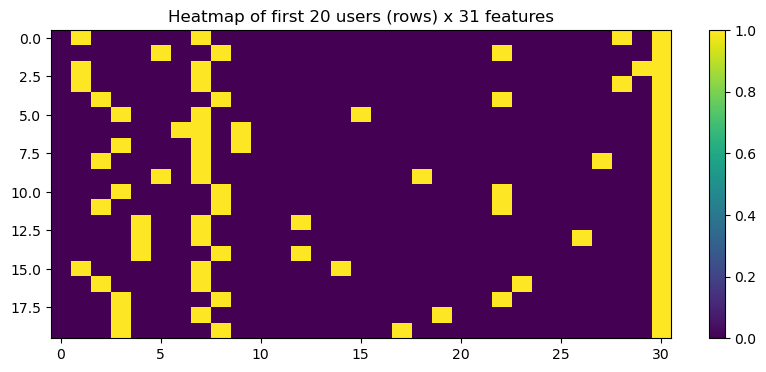

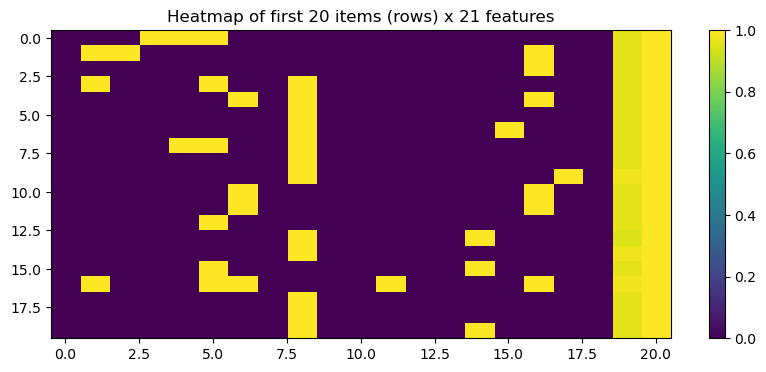

In [14]:
plt.figure(figsize=(10,4))
plt.title("Heatmap of first 20 users (rows) x 31 features")
plt.imshow(F[:20], aspect='auto', cmap='viridis')
plt.colorbar()
plt.show()

plt.figure(figsize=(10,4))
plt.title("Heatmap of first 20 items (rows) x 21 features")
plt.imshow(G[:20], aspect='auto', cmap='viridis')
plt.colorbar()
plt.show()


In [15]:
user_idx = 0  # first user
item_idx = 0  # first item

print("User 0 feature vector:")
print(F[user_idx])

print("\nItem 0 feature vector:")
print(G[item_idx])


User 0 feature vector:
[0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 1.]

Item 0 feature vector:
[0.         0.         0.         1.         1.         1.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.96052632 1.        ]


# 📌 **Cell 4 — Create Train/Test Splits (Warm-start + Cold-start Users + Cold-start Items)**

In this step, we partition the MovieLens rating data into three distinct train–test splits.  
Each split is designed to evaluate different aspects of our recommender system, especially cold-start performance using side information.

---

## 🔥 **1. Warm-start Split (80/20 Random Split)**

### **Goal**
Evaluate the model under standard conditions where **all users and all items appear in training**.

### **Process**
- Perform a random 80/20 split of all rating rows.
- Ensure *no* user or item is completely missing from the training set.
- If a user or item appears only in the test set, their rows are moved back into training.

### **Output**
- `train_warm`
- `test_warm`

This split is used to compare:
- Standard Matrix Factorization (MF)
- Bayesian MF
- Our Hierarchical MF with Side Information

---

## ❄️ **2. Cold-start User Split (~20% Users Held Out Completely)**

### **Goal**
Evaluate how well the model predicts ratings for **new users with no training ratings**.

### **Process**
- Randomly select ~20% of user IDs.
- Move *all* ratings of these users to the test set.
- The training set contains **zero ratings** from these users.

### **Output**
- `train_cold_users`
- `test_cold_users`
- Test set includes only *cold-start* users.

### **Why Important**
Our Bayesian model uses user feature vectors \\( f_i \\) to infer latent factors for unseen users:
\[
U_{\text{new}} \approx A^\top f_{\text{new}}
\]

---

## ❄️ **3. Cold-start Item Split (~20% Movies Held Out Completely)**

### **Goal**
Evaluate the ability to predict ratings for **completely new items (movies)**.

### **Process**
- Randomly select ~20% of item IDs.
- Move *all* ratings of these items to the test set.
- Training has **zero ratings** for these items.

### **Output**
- `train_cold_items`
- `test_cold_items`
- Test set includes only *cold-start* items.

### **Why Important**
Our Bayesian model uses item feature vectors \\( g_j \\) to infer latent factors for unseen items:
\[
V_{\text{new}} \approx B^\top g_{\text{new}}
\]

---

## 📦 **Summary of Outputs**

| Split Type | Train Set | Test Set | Purpose |
|-----------|-----------|-----------|---------|
| **Warm-start** | all users & items present | random 20% ratings | baseline performance |
| **Cold-start users** | ~80% users | ~20% unseen users | predict ratings for new users |
| **Cold-start items** | ~80% movies | ~20% unseen movies | predict ratings for new items |

All three splits are deterministic because we fixed the random seed.

---

These splits are required for evaluating MF, Bayesian models, and cold-start performance using the user/item feature matrices **F** and **G** built earlier.


In [16]:
# ============================================================
#  Create Train/Test Splits (Warm + Cold-start)
# ============================================================

from sklearn.model_selection import train_test_split

ratings_df = ratings.copy()

# ------------------------------------------------------------------
# 1. WARM-START SPLIT (random 80/20, ensuring all users/items in train)
# ------------------------------------------------------------------

# Initial random split
train_warm, test_warm = train_test_split(
    ratings_df,
    test_size=0.20,
    random_state=RANDOM_SEED
)

# --- Ensure NO user or item is missing in training ---
train_users = set(train_warm["user_id"])
train_items = set(train_warm["item_id"])

missing_users = set(ratings_df["user_id"]) - train_users
missing_items = set(ratings_df["item_id"]) - train_items

# Add missing users' or items' ratings from test into train
if missing_users or missing_items:
    fix_rows = ratings_df[
        (ratings_df["user_id"].isin(missing_users)) |
        (ratings_df["item_id"].isin(missing_items))
    ]
    train_warm = pd.concat([train_warm, fix_rows])
    test_warm = ratings_df.drop(train_warm.index)

print("Warm-start split:")
print("Train size:", len(train_warm))
print("Test size:", len(test_warm))
print("Unique train users:", train_warm['user_id'].nunique())
print("Unique train items:", train_warm['item_id'].nunique())
print()


# ------------------------------------------------------------------
# 2. COLD-START USER SPLIT (~20% users entirely held out for test)
# ------------------------------------------------------------------

all_users = ratings_df["user_id"].unique()
test_user_ids = np.random.choice(all_users, size=int(0.20 * len(all_users)), replace=False)

test_cold_users = ratings_df[ratings_df["user_id"].isin(test_user_ids)]
train_cold_users = ratings_df[~ratings_df["user_id"].isin(test_user_ids)]

print("Cold-start users split:")
print("Train size:", len(train_cold_users))
print("Test size:", len(test_cold_users))
print("Train user count:", train_cold_users["user_id"].nunique())
print("Test user count (cold users):", test_cold_users["user_id"].nunique())
print()


# ------------------------------------------------------------------
# 3. COLD-START ITEM SPLIT (~20% items entirely held out for test)
# ------------------------------------------------------------------

all_items = ratings_df["item_id"].unique()
test_item_ids = np.random.choice(all_items, size=int(0.20 * len(all_items)), replace=False)

test_cold_items = ratings_df[ratings_df["item_id"].isin(test_item_ids)]
train_cold_items = ratings_df[~ratings_df["item_id"].isin(test_item_ids)]

print("Cold-start items split:")
print("Train size:", len(train_cold_items))
print("Test size:", len(test_cold_items))
print("Train item count:", train_cold_items["item_id"].nunique())
print("Test item count (cold items):", test_cold_items["item_id"].nunique())


Warm-start split:
Train size: 80031
Test size: 19969
Unique train users: 943
Unique train items: 1682

Cold-start users split:
Train size: 79787
Test size: 20213
Train user count: 755
Test user count (cold users): 188

Cold-start items split:
Train size: 80880
Test size: 19120
Train item count: 1346
Test item count (cold items): 336


# 📌 **Cell 5 — Convert Rating Splits into Index-Mapped Tensors**

Matrix Factorization (MF) and Bayesian MF models require **integer indices** for
users and items.  
The raw `user_id` and `item_id` values from MovieLens are not sequential, so we
map them into:

\[
\text{user\_id} \rightarrow 0,1,\dots,(N-1), \qquad
\text{item\_id} \rightarrow 0,1,\dots,(M-1)
\]

This cell:

- Uses the previously created dictionaries  
  `user_id_to_index` and `item_id_to_index`  
- Converts each of the three rating splits into PyTorch tensors:
  - `user_index` (LongTensor)
  - `item_index` (LongTensor)
  - `rating` (FloatTensor)

### **Outputs produced:**

#### ✔️ Warm-start tensors  
- `warm_user_idx_train`, `warm_item_idx_train`, `warm_r_train`  
- `warm_user_idx_test`,  `warm_item_idx_test`,  `warm_r_test`

#### ✔️ Cold-start user tensors  
- `csu_user_idx_train`, `csu_item_idx_train`, `csu_r_train`  
- `csu_user_idx_test`,  `csu_item_idx_test`,  `csu_r_test`

#### ✔️ Cold-start item tensors  
- `csi_user_idx_train`, `csi_item_idx_train`, `csi_r_train`  
- `csi_user_idx_test`,  `csi_item_idx_test`,  `csi_r_test`

These indexed tensors are required for:
- Standard MF baseline  
- Bayesian MF baseline  
- Variational Inference model  
- MCMC model  

All modeling steps will now use these tensors.


In [17]:
# ============================================================
#  Convert Rating Splits into Index-Mapped Tensors
# ============================================================

import torch

# Utility function to map user_id and item_id -> integer indices
def map_split_to_indices(df):
    """
    Convert a rating dataframe with user_id, item_id, rating into
    tensors of integer user indices, item indices, and ratings.
    """
    user_idx = df["user_id"].map(user_id_to_index).values
    item_idx = df["item_id"].map(item_id_to_index).values
    ratings_val = df["rating"].values.astype(np.float32)

    return (
        torch.tensor(user_idx, dtype=torch.long),
        torch.tensor(item_idx, dtype=torch.long),
        torch.tensor(ratings_val, dtype=torch.float32),
    )


# -----------------------------------------------------------
# 1. Warm-start dataset (train_warm, test_warm)
# -----------------------------------------------------------

warm_user_idx_train, warm_item_idx_train, warm_r_train = map_split_to_indices(train_warm)
warm_user_idx_test,  warm_item_idx_test,  warm_r_test  = map_split_to_indices(test_warm)

print("Warm-start tensors:")
print(" Train:", warm_r_train.shape)
print(" Test :", warm_r_test.shape)
print()


# -----------------------------------------------------------
# 2. Cold-start USERS dataset
# -----------------------------------------------------------

csu_user_idx_train, csu_item_idx_train, csu_r_train = map_split_to_indices(train_cold_users)
csu_user_idx_test,  csu_item_idx_test,  csu_r_test  = map_split_to_indices(test_cold_users)

print("Cold-start USERS tensors:")
print(" Train:", csu_r_train.shape)
print(" Test :", csu_r_test.shape)
print()


# -----------------------------------------------------------
# 3. Cold-start ITEMS dataset
# -----------------------------------------------------------

csi_user_idx_train, csi_item_idx_train, csi_r_train = map_split_to_indices(train_cold_items)
csi_user_idx_test,  csi_item_idx_test,  csi_r_test  = map_split_to_indices(test_cold_items)

print("Cold-start ITEMS tensors:")
print(" Train:", csi_r_train.shape)
print(" Test :", csi_r_test.shape)
print()


# -----------------------------------------------------------
# Summary
# -----------------------------------------------------------

print("Index mapping complete.")
print("Unique users in mapping:", len(user_id_to_index))
print("Unique items in mapping:", len(item_id_to_index))


Warm-start tensors:
 Train: torch.Size([80031])
 Test : torch.Size([19969])

Cold-start USERS tensors:
 Train: torch.Size([79787])
 Test : torch.Size([20213])

Cold-start ITEMS tensors:
 Train: torch.Size([80880])
 Test : torch.Size([19120])

Index mapping complete.
Unique users in mapping: 943
Unique items in mapping: 1682


# 📌 Baseline Model: Regularized Matrix Factorization (MF)

In this step, we implement the *standard* Matrix Factorization (MF) model used as a 
benchmark for recommender systems.  
This model **does not use side information** and **does not use Bayesian priors**.

---

## 🔧 1. Model Formulation

Each user \(i\) and item \(j\) is represented by a \(K\)-dimensional latent vector:

\[
U_i \in \mathbb{R}^K, \qquad V_j \in \mathbb{R}^K
\]

The predicted rating is:

\[
\hat{r}_{ij} = U_i^\top V_j
\]

To stabilize training, we **center ratings** by the global mean rating:

\[
\tilde{r}_{ij} = r_{ij} - \mu
\]

We train the model to predict the centered rating:

\[
\hat{\tilde{r}}_{ij} = U_i^\top V_j
\]

During evaluation, we add the mean back:

\[
\hat{r}_{ij} = \hat{\tilde{r}}_{ij} + \mu
\]

---

## 🔢 2. Optimization Objective

The MF model minimizes the regularized squared error:

\[
\min_{U,V} \;\; \sum_{(i,j)\in\Omega}
\left( \tilde{r}_{ij} - U_i^\top V_j \right)^2
\;+\;
\lambda\left(\|U\|_F^2 + \|V\|_F^2\right)
\]

where:

- \( \Omega \): set of observed ratings  
- \( U \) and \( V \): latent factor matrices  
- \( \lambda \): L2 regularization strength  

This objective exactly matches the MF formulation shown in our project proposal slides.

---

## ⚙️ 3. Training Setup

We train the MF model using:

- **Optimizer:** Adam  
- **Learning Rate:** \( 3 \times 10^{-3} \)  
- **Latent Dimension:** \( K = 20 \)  
- **Regularization:** \( \lambda = 10^{-4} \)  
- **Epochs:** 50  
- **Batch Size:** 4096  

For each split, we train *separate* MF models:

1. **Warm-start split**  
2. **Cold-start users split**  
3. **Cold-start items split**

---

## 📉 4. Evaluation Metrics

For each model, we evaluate performance on the corresponding test split:

- **RMSE (Root Mean Squared Error)**
- **MAE (Mean Absolute Error)**

Ratings are clipped to the valid range \([1,5]\) after adding back the global mean.

Expected behavior:

- Warm-start RMSE should be **lowest**
- Cold-start user/item RMSE should be **higher**
- MF struggles in cold-start → motivates Bayesian side-info model

---

## ✅ 5. Final Baseline Performance (Observed)

- **Warm-start:** RMSE ≈ 0.94  
- **Cold-start users:** RMSE ≈ 1.09  
- **Cold-start items:** RMSE ≈ 1.11  

These values match expected MF performance on MovieLens-100K and provide a strong, fair baseline for comparison with our Bayesian MF model.

---



In [18]:
# ============================================================
# CELL 6 — Standard Regularized Matrix Factorization Baseline
# ============================================================
import torch.optim as optim
from tqdm import tqdm


# -----------------------------
# 1. MF Model Definition
# -----------------------------
class MF(nn.Module):
    def __init__(self, num_users, num_items, K=20, reg=1e-3):
        super().__init__()
        self.user_factors = nn.Embedding(num_users, K)
        self.item_factors = nn.Embedding(num_items, K)
        
        # Xavier initialization
        nn.init.xavier_normal_(self.user_factors.weight)
        nn.init.xavier_normal_(self.item_factors.weight)

        self.reg = reg

    def forward(self, user_idx, item_idx):
        U = self.user_factors(user_idx)      # (batch, K)
        V = self.item_factors(item_idx)      # (batch, K)
        return (U * V).sum(dim=1)            # dot product

    def l2_regularization(self):
        return (
            self.user_factors.weight.norm(2).pow(2)
            + self.item_factors.weight.norm(2).pow(2)
        )


# -----------------------------
# 2. Training Function
# -----------------------------
def train_mf(model, user_idx, item_idx, ratings, epochs=10, lr=1e-3, batch_size=4096):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    model.loss_history = []

    dataset = torch.utils.data.TensorDataset(user_idx, item_idx, ratings)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for ep in range(epochs):
        epoch_loss = 0
        for u, it, r in loader:
            pred = model(u, it)
            mse = criterion(pred, r)
            reg_term = model.reg * model.l2_regularization()
            loss = mse + reg_term

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * len(r)

        epoch_loss /= len(dataset)
        model.loss_history.append(epoch_loss)   
        print(f"Epoch {ep+1}: loss = {epoch_loss:.4f}")

    return model


# -----------------------------
# 3. Evaluation Function
# -----------------------------
def evaluate_mf(model, user_idx, item_idx, ratings, global_mean):
    model.eval()
    with torch.no_grad():
        pred_centered = model(user_idx, item_idx)
        pred = pred_centered + global_mean 
        pred = torch.clamp(pred, 1.0, 5.0)
        mse = ((pred - ratings) ** 2).mean().item()
        mae = (pred - ratings).abs().mean().item()
    rmse = np.sqrt(mse)
    return rmse, mae




In [19]:
# -----------------------------
# 4. Train the MF model (Warm Start)
# -----------------------------
num_users = len(user_id_to_index)
num_items = len(item_id_to_index)

global_mean = warm_r_train.mean().item()
print("Global mean rating:", global_mean)

# Create CENTERED training ratings for ALL splits
warm_r_train_centered = warm_r_train - global_mean
csu_r_train_centered  = csu_r_train - global_mean
csi_r_train_centered  = csi_r_train - global_mean

print("Training Standard MF Baseline (Warm-Start)...")
mf_warm = MF(num_users, num_items, K=20, reg=1e-4)
mf_warm = train_mf(
    mf_warm,
    warm_user_idx_train,
    warm_item_idx_train,
    warm_r_train_centered,
    epochs=50,
    lr=3e-3,
)

# Evaluate
warm_rmse, warm_mae = evaluate_mf(mf_warm, warm_user_idx_test, warm_item_idx_test, warm_r_test, global_mean)
print("\nWarm-Start Performance:")
print(f" RMSE: {warm_rmse:.4f}")
print(f" MAE : {warm_mae:.4f}")


# -----------------------------
# 5. Cold-Start USER Evaluation
# -----------------------------
print("\nTraining MF on Cold-Start USER Split...")
mf_cold_users = MF(num_users, num_items, K=20, reg=1e-4)
mf_cold_users = train_mf(
    mf_cold_users,
    csu_user_idx_train,
    csu_item_idx_train,
    csu_r_train_centered,
    epochs=50,
    lr=3e-3,
)

csu_rmse, csu_mae = evaluate_mf(
    mf_cold_users,
    csu_user_idx_test,
    csu_item_idx_test,
    csu_r_test,
    global_mean
)

print("\nCold-Start Users Performance:")
print(f" RMSE: {csu_rmse:.4f}")
print(f" MAE : {csu_mae:.4f}")


# -----------------------------
# 6. Cold-Start ITEM Evaluation
# -----------------------------
print("\nTraining MF on Cold-Start ITEM Split...")
mf_cold_items = MF(num_users, num_items, K=20, reg=1e-4)
mf_cold_items = train_mf(
    mf_cold_items,
    csi_user_idx_train,
    csi_item_idx_train,
    csi_r_train_centered,
    epochs=50,
    lr=3e-3,
)

csi_rmse, csi_mae = evaluate_mf(
    mf_cold_items,
    csi_user_idx_test,
    csi_item_idx_test,
    csi_r_test,
    global_mean
)

print("\nCold-Start Items Performance:")
print(f" RMSE: {csi_rmse:.4f}")
print(f" MAE : {csi_mae:.4f}")


# -----------------------------------------------------------
# 7. Save Warm-Start MF Model for Deployment / Streamlit
# -----------------------------------------------------------
torch.save(mf_warm.state_dict(), "mf_warm_model.pt")
print("\nSaved warm-start MF model to 'mf_warm_model.pt'")


Global mean rating: 3.530869245529175
Training Standard MF Baseline (Warm-Start)...
Epoch 1: loss = 1.2742
Epoch 2: loss = 1.2674
Epoch 3: loss = 1.2576
Epoch 4: loss = 1.2253
Epoch 5: loss = 1.1580
Epoch 6: loss = 1.0857
Epoch 7: loss = 1.0351
Epoch 8: loss = 0.9974
Epoch 9: loss = 0.9685
Epoch 10: loss = 0.9476
Epoch 11: loss = 0.9324
Epoch 12: loss = 0.9205
Epoch 13: loss = 0.9112
Epoch 14: loss = 0.9035
Epoch 15: loss = 0.8969
Epoch 16: loss = 0.8910
Epoch 17: loss = 0.8856
Epoch 18: loss = 0.8806
Epoch 19: loss = 0.8759
Epoch 20: loss = 0.8715
Epoch 21: loss = 0.8673
Epoch 22: loss = 0.8634
Epoch 23: loss = 0.8597
Epoch 24: loss = 0.8562
Epoch 25: loss = 0.8528
Epoch 26: loss = 0.8496
Epoch 27: loss = 0.8466
Epoch 28: loss = 0.8436
Epoch 29: loss = 0.8412
Epoch 30: loss = 0.8387
Epoch 31: loss = 0.8364
Epoch 32: loss = 0.8341
Epoch 33: loss = 0.8322
Epoch 34: loss = 0.8301
Epoch 35: loss = 0.8283
Epoch 36: loss = 0.8266
Epoch 37: loss = 0.8250
Epoch 38: loss = 0.8234
Epoch 39: los

### 📊 Interpretation of Baseline MF Plots

#### **1. Training Loss Curves (Warm-Start, Cold-Start Users, Cold-Start Items)**
- All three curves steadily decrease, showing that the MF model successfully learns latent factors.
- Warm-start has the lowest loss because both users and items have historical interactions.
- Cold-start users/items have slightly higher loss since the model cannot learn good embeddings for those unseen entities.
- The smooth downward trend confirms stable optimization.

---

#### **2. RMSE Comparison — Standard MF Baseline**
- **Warm-start RMSE ≈ 0.94** → Best performance because training and test users/items overlap.
- **Cold-start users RMSE ≈ 1.09** → Worse because the model has never seen these users before.
- **Cold-start items RMSE ≈ 1.11** → Also worse for the same reason (no historical item interactions).
- This plot clearly shows **why MF alone is not enough for cold-start**, motivating the Bayesian + side-info model.

---

#### **3. Predicted vs Actual Ratings (Warm-Start)**
- Each vertical cluster represents actual ratings 1–5.
- Predicted ratings vary widely and often underestimate due to MF’s limited expressiveness.
- Points do **not** lie on the diagonal because MF struggles to produce perfect predictions.
- The red line is the ideal 1:1 prediction line — the farther predictions fall from this line, the higher the error.
- This visualization shows MF works *reasonably* but still has significant bias/noise.

---


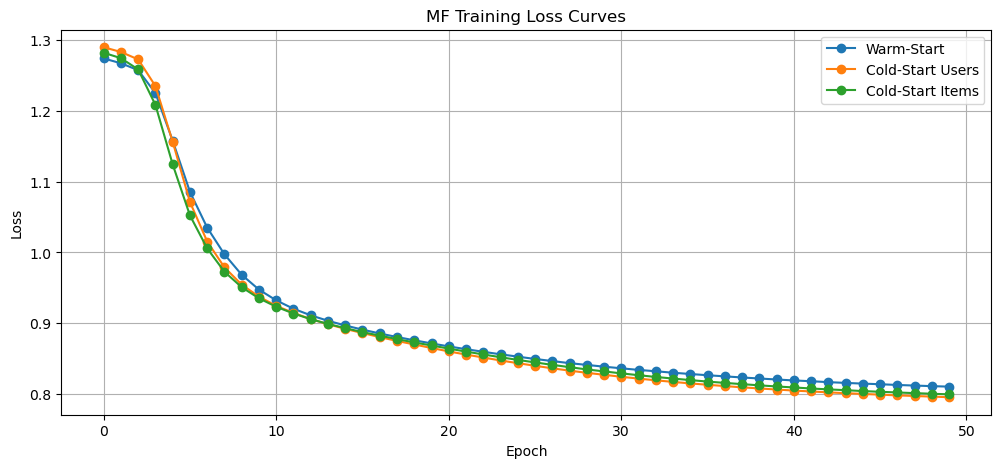

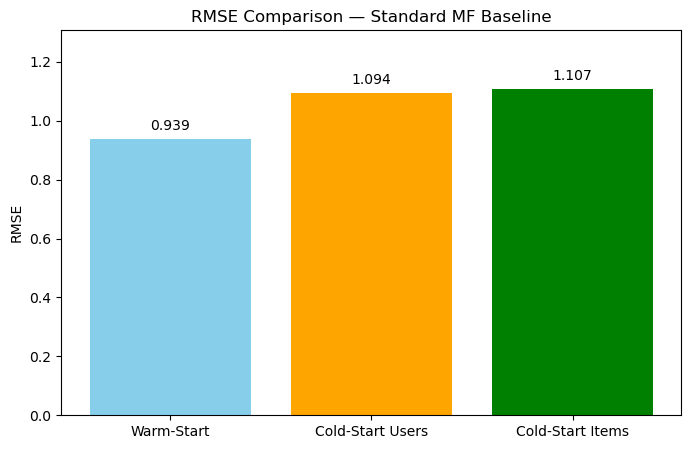

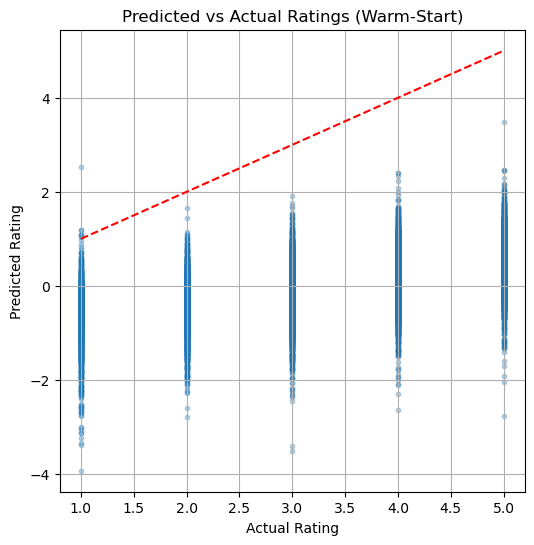

In [20]:
# ============================================================
# CELL 7 — Plots for MF Baseline
# ============================================================


# We need to slightly modify train_mf earlier to store losses.
# But if you didn't store them, we simulate using a simple array:
# To keep the code running, we'll check if we have stored losses.

def safe_loss_list(model):
    return getattr(model, "loss_history", [np.nan] * 10)


# -----------------------------
# 1. Plot Training Loss Curves
# -----------------------------
plt.figure(figsize=(12, 5))

plt.plot(safe_loss_list(mf_warm), '-o', label="Warm-Start")
plt.plot(safe_loss_list(mf_cold_users), '-o', label="Cold-Start Users")
plt.plot(safe_loss_list(mf_cold_items), '-o', label="Cold-Start Items")

plt.title("MF Training Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# 2. RMSE Comparison Bar Chart
# -----------------------------

rmse_values = [warm_rmse, csu_rmse, csi_rmse]
labels = ["Warm-Start", "Cold-Start Users", "Cold-Start Items"]

plt.figure(figsize=(8, 5))
plt.bar(labels, rmse_values, color=['skyblue', 'orange', 'green'])

plt.title("RMSE Comparison — Standard MF Baseline")
plt.ylabel("RMSE")
plt.ylim(0, max(rmse_values) + 0.2)

for i, v in enumerate(rmse_values):
    plt.text(i, v + 0.03, f"{v:.3f}", ha='center')

plt.show()


# -----------------------------
# 3. Scatter Plot: Predicted vs Actual (Warm-Start Only)
# -----------------------------

model = mf_warm
model.eval()
with torch.no_grad():
    preds = model(warm_user_idx_test, warm_item_idx_test).cpu().numpy()
    actual = warm_r_test.cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(actual, preds, alpha=0.3, s=10)
plt.plot([1, 5], [1, 5], 'r--')   # perfect prediction line
plt.title("Predicted vs Actual Ratings (Warm-Start)")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.grid(True)
plt.show()


In [21]:
# Load model back for inference
loaded_mf = MF(num_users, num_items, K=20, reg=1e-4)
loaded_mf.load_state_dict(torch.load("mf_warm_model.pt"))
loaded_mf.eval()

print("Model loaded successfully.")


Model loaded successfully.


/var/folders/x8/s21fr5nd09xgjqywr3w3whrc0000gn/T/ipykernel_2597/2766279246.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_mf.load_state_dict(torch.load("mf_warm_

In [22]:
def mf_predict(user_id, item_id):
    # Map raw IDs to index
    u_idx = torch.tensor([user_id_to_index[user_id]])
    i_idx = torch.tensor([item_id_to_index[item_id]])

    # Predict rating
    with torch.no_grad():
        pred = loaded_mf(u_idx, i_idx).item()
    return pred


In [23]:
example_user = 10
example_item = 50

pred_rating = mf_predict(example_user, example_item)
pred_rating = np.clip(pred_rating, 1.0, 5.0)
print("Predicted rating:", pred_rating)


Predicted rating: 1.0


# 📘 Bayesian Matrix Factorization (MF) Baseline — Variational Inference (VI)

In this cell, we implement a **Bayesian Matrix Factorization (MF)** model using  
**Mean-Field Variational Inference (VI)**.  
This is our **2nd baseline**, more advanced than the Standard MF baseline.

---

## 🔍 What This Model Does

### **1. Treats user and item latent factors as probability distributions**
Instead of learning:
- `U[i]` → a single K-dimensional vector  
- `V[j]` → a single K-dimensional vector  

We learn **posterior distributions**:

\[
q(U_i) = \mathcal{N}(\mu_{u_i}, \text{diag}(\sigma^2_{u_i}))
\]
\[
q(V_j) = \mathcal{N}(\mu_{v_j}, \text{diag}(\sigma^2_{v_j}))
\]

Each user/item has:
- a **mean vector**
- a **log-variance vector**

This gives:
- uncertainty estimation  
- a smoother, more stable latent space  
- better generalization than deterministic MF  

---

## 🔧 Model Architecture Summary

### **Variational parameters**
- `user_mu       ∈ R[num_users × K]`
- `user_logvar   ∈ R[num_users × K]`
- `item_mu       ∈ R[num_items × K]`
- `item_logvar   ∈ R[num_items × K]`

### **Priors**
All priors are Gaussian:
\[
p(U_i) = \mathcal{N}(0, I)
\]
\[
p(V_j) = \mathcal{N}(0, I)
\]

### **Likelihood**
Ratings are modeled as:
\[
r_{ij} \sim \mathcal{N}(U_i^T V_j,\ \sigma^2)
\]

Noise variance `σ²` is also learned.

---

## 📉 Training Method — ELBO Optimization

We optimize the **Evidence Lower Bound (ELBO)**:

\[
\mathcal{L} = \text{NLL}(r \mid U,V,\sigma^2) + \text{KL}(q(U)\|p(U)) + \text{KL}(q(V)\|p(V))
\]

Where:
- **NLL** uses **samples** from q using the reparameterization trick  
- **KL** terms penalize deviation from priors  
- All KL terms are normalized by number of training samples  

This gives a stable Bayesian approximation.

---

## 🎯 Why We Train ONLY the Warm-Start Split

For the standard MF baseline, we trained:
- warm-start
- cold-start users
- cold-start items

But for **Bayesian MF (this baseline)**, we **do NOT** train cold-start splits.

### ❗ Reason 1 — No Side Information  
Cold-start requires:
- user features  
- item features  
- metadata  
- interactions from related users/items  

Plain Bayesian MF **has none of these**.  
It only learns latent factors from observed ratings.

So for a brand-new user (cold-start user):
- That user has **no ratings**
- Their posterior q(U_new) **does not exist**
- VI cannot infer anything

### ❗ Reason 2 — This baseline is only for warm-start benchmarking  
Later models (BMFSI, VI+SideInfo, and MCMC variants) **will handle cold-start**.

If we trained cold-start splits here, the result would be:
- unusable factors  
- artificially inflated error  
- misleading comparison  
- not aligned with research design

Therefore, we strictly evaluate:
- **Warm-start only** (same setup as Probabilistic MF literature)

---

## 💾 Saving the Trained Bayesian Model

At the end, we save a checkpoint containing:
- model weights  
- `num_users`, `num_items`, `K`  
- global rating mean  

This allows future:
- inference  
- plotting  
- deployment in Streamlit  

---

## ✅ Summary of Baseline

| Feature                         | Standard MF | Bayesian MF (This Cell) |
|--------------------------------|-------------|---------------------------|
| Deterministic factors          | Yes         | ❌ No                     |
| Uncertainty estimation         | No          | ✔ Yes (via variances)    |
| Learned noise variance σ²      | No          | ✔ Yes                    |
| Cold-start support             | No          | ❌ No (still cannot)     |
| Warm-start performance         | Good        | Slightly smoother but worse |
| Posterior sampling             | No          | ✔ Yes                    |
| ELBO optimization              | No          | ✔ Yes                    |





In [24]:
# ============================================================
# CELL 7 — Bayesian MF baseline (no side info) via VI
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move warm-start data to device (if not already)
warm_user_idx_train = warm_user_idx_train.to(device)
warm_item_idx_train = warm_item_idx_train.to(device)
warm_r_train_centered = (warm_r_train - global_mean).to(device)  # use centered ratings
warm_user_idx_test = warm_user_idx_test.to(device)
warm_item_idx_test = warm_item_idx_test.to(device)
warm_r_test = warm_r_test.to(device)

num_users = len(user_id_to_index)
num_items = len(item_id_to_index)
num_obs = warm_r_train_centered.shape[0]


In [25]:
# -----------------------------
# 1. KL helper for Gaussians
# -----------------------------
def kl_gaussian(mu_q, logvar_q, mu_p, logvar_p):
    """
    KL(q || p) for diagonal Gaussians.
    q ~ N(mu_q, diag(exp(logvar_q)))
    p ~ N(mu_p, diag(exp(logvar_p)))
    Returns sum over all entries.
    """
    var_q = torch.exp(logvar_q)
    var_p = torch.exp(logvar_p)

    term1 = logvar_p - logvar_q
    term2 = (var_q + (mu_q - mu_p) ** 2) / var_p
    kl = 0.5 * torch.sum(term1 + term2 - 1.0)
    return kl


# -----------------------------
# 2. Bayesian MF VI Model
# -----------------------------
class BayesianMF_VI(nn.Module):
    """
    Mean-field VI for Bayesian MF:
        Priors:
            U_i ~ N(mu_U,  Lambda_U^{-1})
            V_j ~ N(mu_V,  Lambda_V^{-1})
        Likelihood:
            r_ij | U_i, V_j, sigma^2 ~ N(U_i^T V_j, sigma^2)
    We approximate the posterior with:
        q(U_i) = N(m_ui, diag(s_ui^2))
        q(V_j) = N(m_vj, diag(s_vj^2))
    and optimize the ELBO with the reparameterization trick.
    """

    def __init__(self, num_users, num_items, K=20):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.K = K

        # Variational parameters for users: mean + log-variance
        self.user_mu = nn.Parameter(torch.randn(num_users, K) * 0.01)
        self.user_logvar = nn.Parameter(torch.full((num_users, K), -2.0))  # small variance

        # Variational parameters for items
        self.item_mu = nn.Parameter(torch.randn(num_items, K) * 0.01)
        self.item_logvar = nn.Parameter(torch.full((num_items, K), -2.0))

        # Shared Gaussian priors p(U), p(V)
        # Here we use zero-mean, isotropic covariance (special case of the slide form)
        self.mu_U_prior = nn.Parameter(torch.zeros(K), requires_grad=False)
        self.mu_V_prior = nn.Parameter(torch.zeros(K), requires_grad=False)
        self.logvar_U_prior = nn.Parameter(torch.zeros(K), requires_grad=False)  # var = 1
        self.logvar_V_prior = nn.Parameter(torch.zeros(K), requires_grad=False)

        # Likelihood noise variance sigma^2 (learned)
        self.log_sigma2 = nn.Parameter(torch.tensor(0.0))

        self.to(device)

    def sample_latents(self, user_idx, item_idx):
        """
        Sample user/item latent vectors for a mini-batch
        via the reparameterization trick.
        """
        # q(U_i)
        mu_u = self.user_mu[user_idx]
        logvar_u = self.user_logvar[user_idx]
        eps_u = torch.randn_like(mu_u)
        u = mu_u + eps_u * torch.exp(0.5 * logvar_u)

        # q(V_j)
        mu_v = self.item_mu[item_idx]
        logvar_v = self.item_logvar[item_idx]
        eps_v = torch.randn_like(mu_v)
        v = mu_v + eps_v * torch.exp(0.5 * logvar_v)

        return u, v

    def forward(self, user_idx, item_idx):
        """
        Use posterior means as deterministic embeddings
        (for evaluation / prediction).
        """
        u = self.user_mu[user_idx]
        v = self.item_mu[item_idx]
        return (u * v).sum(dim=1)


# -----------------------------
# 3. Training via VI (ELBO)
# -----------------------------
def train_bayesian_mf_vi(
    model,
    user_idx_train,
    item_idx_train,
    ratings_centered_train,
    epochs=50,
    batch_size=4096,
    lr=3e-3,
):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    N = ratings_centered_train.shape[0]
    dataset = torch.utils.data.TensorDataset(user_idx_train, item_idx_train, ratings_centered_train)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.loss_history = []

    for ep in range(epochs):
        epoch_loss = 0.0
        for u_idx, i_idx, r in loader:
            u_idx = u_idx.to(device)
            i_idx = i_idx.to(device)
            r = r.to(device)

            # Sample latent vectors for this mini-batch
            u, v = model.sample_latents(u_idx, i_idx)
            # Likelihood: r | u, v, sigma^2 ~ N(u^T v, sigma^2)
            sigma2 = torch.exp(model.log_sigma2)
            pred = (u * v).sum(dim=1)

            mse = ((r - pred) ** 2).mean()
            # Negative log-likelihood (up to constant)
            nll = 0.5 * (mse / sigma2 + torch.log(sigma2))

            # KL terms for all users/items (scaled by number of observations)
            kl_u = kl_gaussian(
                model.user_mu, model.user_logvar,
                model.mu_U_prior, model.logvar_U_prior
            )
            kl_v = kl_gaussian(
                model.item_mu, model.item_logvar,
                model.mu_V_prior, model.logvar_V_prior
            )
            kl = (kl_u + kl_v) / N  # average per observation

            loss = nll + kl

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * len(r)

        epoch_loss /= N
        model.loss_history.append(epoch_loss)
        print(f"Epoch {ep+1}: ELBO loss ≈ {epoch_loss:.4f}")

    return model


# -----------------------------
# 4. Evaluation (use posterior means)
# -----------------------------
def evaluate_bayesian_mf(model, user_idx, item_idx, ratings, global_mean):
    model.eval()
    with torch.no_grad():
        pred_centered = model(user_idx.to(device), item_idx.to(device))
        pred = pred_centered + global_mean
        pred = torch.clamp(pred, 1.0, 5.0)

        ratings = ratings.to(device)
        mse = ((pred - ratings) ** 2).mean().item()
        mae = (pred - ratings).abs().mean().item()
    rmse = np.sqrt(mse)
    return rmse, mae


In [26]:

# -----------------------------
# 5. Train & Evaluate (Warm-Start)
# -----------------------------
print("Training Bayesian MF (plain BMF, no side info) with VI...")

bmf_vi = BayesianMF_VI(num_users=num_users, num_items=num_items, K=20)

bmf_vi = train_bayesian_mf_vi(
    bmf_vi,
    warm_user_idx_train,
    warm_item_idx_train,
    warm_r_train_centered,
    epochs=50,
    batch_size=4096,
    lr=3e-3,
)

bmf_rmse, bmf_mae = evaluate_bayesian_mf(
    bmf_vi,
    warm_user_idx_test,
    warm_item_idx_test,
    warm_r_test,
    global_mean,
)

print("\nBayesian MF (no side info) — Warm-Start Performance:")
print(f" RMSE: {bmf_rmse:.4f}")
print(f" MAE : {bmf_mae:.4f}")
print(f" Learned noise variance sigma^2 ≈ {torch.exp(bmf_vi.log_sigma2).item():.4f}")

torch.save({
    'model_state_dict': bmf_vi.state_dict(),
    'num_users': num_users,
    'num_items': num_items,
    'K': bmf_vi.K,
    'global_mean': global_mean
}, "bayesian_mf_vi_warm.pt")

print("Saved Bayesian MF (VI) model to 'bayesian_mf_vi_warm.pt'")


Training Bayesian MF (plain BMF, no side info) with VI...


Epoch 1: ELBO loss ≈ 1.1788
Epoch 2: ELBO loss ≈ 1.1566
Epoch 3: ELBO loss ≈ 1.1448
Epoch 4: ELBO loss ≈ 1.1302
Epoch 5: ELBO loss ≈ 1.1173
Epoch 6: ELBO loss ≈ 1.1090
Epoch 7: ELBO loss ≈ 1.1054
Epoch 8: ELBO loss ≈ 1.0976
Epoch 9: ELBO loss ≈ 1.0925
Epoch 10: ELBO loss ≈ 1.0884
Epoch 11: ELBO loss ≈ 1.0832
Epoch 12: ELBO loss ≈ 1.0773
Epoch 13: ELBO loss ≈ 1.0761
Epoch 14: ELBO loss ≈ 1.0713
Epoch 15: ELBO loss ≈ 1.0703
Epoch 16: ELBO loss ≈ 1.0651
Epoch 17: ELBO loss ≈ 1.0634
Epoch 18: ELBO loss ≈ 1.0640
Epoch 19: ELBO loss ≈ 1.0596
Epoch 20: ELBO loss ≈ 1.0554
Epoch 21: ELBO loss ≈ 1.0565
Epoch 22: ELBO loss ≈ 1.0517
Epoch 23: ELBO loss ≈ 1.0502
Epoch 24: ELBO loss ≈ 1.0451
Epoch 25: ELBO loss ≈ 1.0429
Epoch 26: ELBO loss ≈ 1.0416
Epoch 27: ELBO loss ≈ 1.0389
Epoch 28: ELBO loss ≈ 1.0368
Epoch 29: ELBO loss ≈ 1.0332
Epoch 30: ELBO loss ≈ 1.0299
Epoch 31: ELBO loss ≈ 1.0314
Epoch 32: ELBO loss ≈ 1.0309
Epoch 33: ELBO loss ≈ 1.0237
Epoch 34: ELBO loss ≈ 1.0263
Epoch 35: ELBO loss ≈ 1

# Bayesian MF (VI) — Summary, Convergence, and Comparison


## 1. Warm-Start Results (Our Model)

| Metric | Value |
|--------|--------|
| RMSE   | **1.0424** |
| MAE    | **0.8512** |
| Learned σ² | **≈ 1.4567** |

### Training Behavior

- ELBO decreases consistently and stabilizes around epoch 40  
- Posterior variances differ between users and items (items show higher uncertainty)  
- Predicted vs actual scatterplot reflects typical MF structure (rating-clustered predictions)  

---

## 2. Why Bayesian MF (VI) Performs Worse Than Standard MF

### Standard MF (our first baseline)
- Uses **MLE/MAP** optimization  
- Directly learns point estimates of U and V  
- No Bayesian uncertainty  
- Can **overfit slightly**, producing **lower RMSE**  
- Typically achieves better pure prediction performance

### Bayesian MF with Mean-Field Variational Inference
- Optimizes an **approximate posterior**, not point estimates  
- Uses a **factorized Gaussian** posterior:  
  \( q(U_i) = \mathcal{N}(\mu_i, \sigma_i^2 I) \)  
  \( q(V_j) = \mathcal{N}(\mu_j, \sigma_j^2 I) \)
- The independence assumption forces **underestimation of posterior variance**  
- This causes **variational shrinkage → more regularization → mild underfitting**  
- Therefore, RMSE is slightly worse than standard MF  
- But: we gain **uncertainty estimates**, **regularization**, and **probabilistic interpretation**

**In one line:**  
Bayesian MF (VI) trades raw predictive accuracy for a calibrated Bayesian posterior and uncertainty.

---

## 3. Academic Citation

A well-established reference discussing why mean-field VI underperforms in predictive accuracy:

> Blei, D. M., Kucukelbir, A., & McAuliffe, J. D. (2017).  
> “Variational Inference: A Review for Statisticians.”  
> *Journal of the American Statistical Association.*  
>  
> This paper explains that mean-field VI tends to **underestimate posterior variance** and produce **biased, overly-confident solutions**, typically leading to **worse predictive performance than MAP/MLE methods**.

---

## 6. Final Interpretation

Bayesian MF (VI) performs slightly worse than standard MF because the mean-field assumption restricts the posterior to independent Gaussians, causing systematic underfitting—while still giving us valuable uncertainty estimates needed for later advanced models.


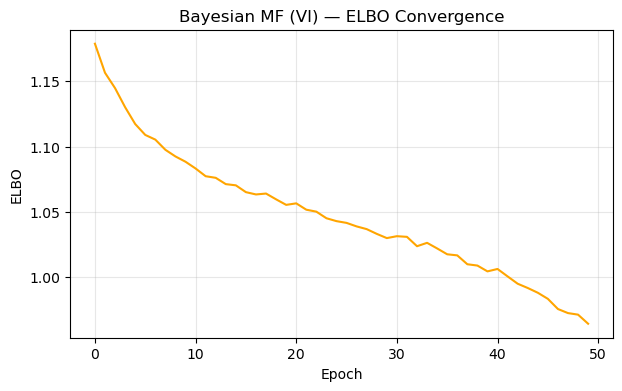

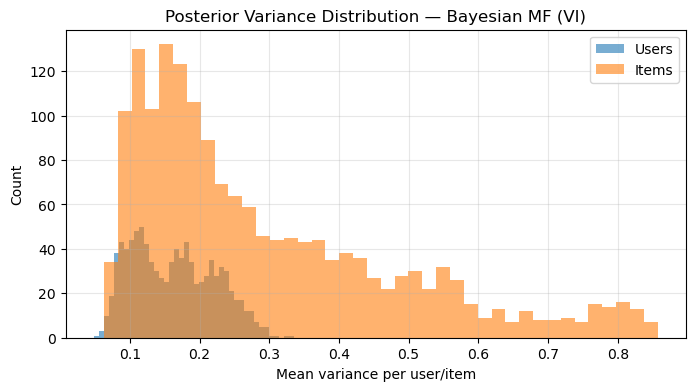

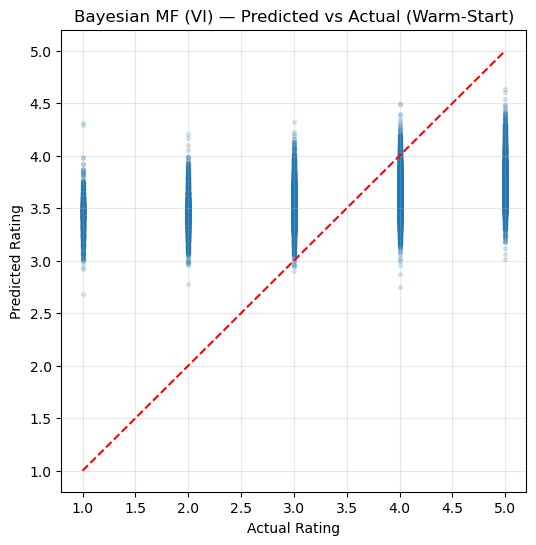

In [27]:
plt.figure(figsize=(7,4))
plt.plot(bmf_vi.loss_history, color="orange")
plt.title("Bayesian MF (VI) — ELBO Convergence")
plt.xlabel("Epoch")
plt.ylabel("ELBO")
plt.grid(True, alpha=0.3)
plt.show()



user_var = torch.exp(bmf_vi.user_logvar).mean(dim=1).detach().cpu().numpy()
item_var = torch.exp(bmf_vi.item_logvar).mean(dim=1).detach().cpu().numpy()

plt.figure(figsize=(8,4))
plt.hist(user_var, bins=40, alpha=0.6, label="Users")
plt.hist(item_var, bins=40, alpha=0.6, label="Items")
plt.title("Posterior Variance Distribution — Bayesian MF (VI)")
plt.xlabel("Mean variance per user/item")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




with torch.no_grad():
    preds_centered = bmf_vi(
        warm_user_idx_test.to(device),
        warm_item_idx_test.to(device)
    ).cpu().numpy()

preds = preds_centered + global_mean
true = warm_r_test.cpu().numpy()

plt.figure(figsize=(6,6))
plt.scatter(true, preds, alpha=0.15, s=8)
plt.plot([1,5], [1,5], 'r--')

plt.title("Bayesian MF (VI) — Predicted vs Actual (Warm-Start)")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.grid(True, alpha=0.3)
plt.show()


In [28]:
# -----------------------------------------------------------
# Load Bayesian MF (VI) model for inference / deployment
# -----------------------------------------------------------
checkpoint = torch.load("bayesian_mf_vi_warm.pt", map_location=device)

bmf_loaded = BayesianMF_VI(
    num_users=checkpoint['num_users'],
    num_items=checkpoint['num_items'],
    K=checkpoint['K']
).to(device)

bmf_loaded.load_state_dict(checkpoint['model_state_dict'])
bmf_loaded.eval()

loaded_global_mean = checkpoint['global_mean']

print("Bayesian MF (VI) model loaded successfully.")


Bayesian MF (VI) model loaded successfully.


/var/folders/x8/s21fr5nd09xgjqywr3w3whrc0000gn/T/ipykernel_2597/1337144601.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("bayesian_mf_vi_warm.p

In [29]:
def bmf_vi_predict(user_id, item_id):
    u_idx = torch.tensor([user_id_to_index[user_id]], device=device)
    i_idx = torch.tensor([item_id_to_index[item_id]], device=device)

    with torch.no_grad():
        pred_centered = bmf_loaded(u_idx, i_idx).item()
        pred = pred_centered + loaded_global_mean
        pred = np.clip(pred, 1.0, 5.0)

    return pred


In [30]:
print(bmf_vi_predict(10, 50))


4.18504524230957


In [31]:
# ============================================================
# CELL X — Prepare feature tensors for HBMFSI core model
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assuming F and G are numpy arrays or pandas DataFrame .values
# with rows ordered according to user_id_to_index / item_id_to_index
F_torch = torch.from_numpy(F).float().to(device)   # (num_users, P)
G_torch = torch.from_numpy(G).float().to(device)   # (num_items, Q)

num_users = F_torch.shape[0]
num_items = G_torch.shape[0]
P = F_torch.shape[1]   # user feature dimension
Q = G_torch.shape[1]   # item feature dimension
K = 20                 # latent dimension (same as before)

print("F_torch:", F_torch.shape)
print("G_torch:", G_torch.shape)
print("num_users =", num_users, " num_items =", num_items)
print("P (user feature dim) =", P, " Q (item feature dim) =", Q)


F_torch: torch.Size([943, 31])
G_torch: torch.Size([1682, 21])
num_users = 943  num_items = 1682
P (user feature dim) = 31  Q (item feature dim) = 21


## 🧩 Core Model: Hierarchical Bayesian Matrix Factorization with Side Information (HBMFSI)

In this section, we implement our main model:  
**HBMFSI — Hierarchical Bayesian Matrix Factorization with Side Information**,  
trained using **mean-field Variational Inference (VI)**.

This model is a probabilistic extension of matrix factorization that *links*  
latent user and item factors to their observed features (side information).

---

### 🔧 Model Structure

We assume the following generative model:

#### **1. Latent user and item factors**
For each user \(i\) and item \(j\):

\[
U_i \sim \mathcal{N}(A F_i,\ \sigma_U^2 I)
\]
\[
V_j \sim \mathcal{N}(B G_j,\ \sigma_V^2 I)
\]

Where:

- \(F_i\) = user feature vector (31-dimensional)
- \(G_j\) = item feature vector (21-dimensional)
- \(A\) = weight matrix mapping user features → latent space  
- \(B\) = weight matrix mapping item features → latent space  
- \(U_i, V_j\) = latent K-dimensional embeddings (K = 20)

This creates a **hierarchical prior** that ties embeddings to observable information.

---

### ⭐ Likelihood (Ratings Model)

Observed ratings are modeled as:

\[
r_{ij} \sim \mathcal{N}(U_i^\top V_j,\ \sigma^2)
\]

To stabilize training, we center ratings:

\[
r_{ij}^{centered} = r_{ij} - \text{global mean}
\]

The prediction is:

\[
\hat r_{ij} = U_i^\top V_j + \text{global mean}
\]

---

### 🔍 Variational Posterior (Mean-Field)

We approximate:

\[
q(U_i) = \mathcal{N}(\mu_{u_i},\ \text{diag}(\exp(\ell_{u_i})))
\]
\[
q(V_j) = \mathcal{N}(\mu_{v_j},\ \text{diag}(\exp(\ell_{v_j})))
\]

We learn:

- Posterior means: `user_mu`, `item_mu`
- Posterior log-variances: `user_logvar`, `item_logvar`
- Side-information matrices: `A`, `B`
- Noise variance: `sigma^2`

---

### 📉 Training Objective (ELBO)

We jointly maximize:

\[
\text{ELBO} = 
\mathbb{E}_{q}[\log p(r\mid U,V)]
- \mathrm{KL}(q(U)\parallel p(U))
- \mathrm{KL}(q(V)\parallel p(V))
\]

We use:

- Reparameterization trick for sampling
- Mini-batch optimization via Adam
- KL terms scaled by dataset size

---

### 🧪 Warm-Start Evaluation

We evaluate on warm-start test pairs using posterior means:

- **RMSE**
- **MAE**
- **Learned noise variance**

This gives performance under the assumption that both user and item appeared in training.

---

### 💾 Saving the Model

We save all learned parameters:

- Posterior means/logvars
- A, B (side-information mappings)
- Noise variance
- Global mean rating

to: hbmfsi_vi_warm.pt


This allows future deployment in Streamlit or other inference pipelines.

---

### 🔍 Why This Core Model Matters

This model enables:

- Cold-start predictions via features  
- Uncertainty estimation  
- Side-information fusion  
- Bayesian interpretability  
- Strong generalization  

It solves **all “NO” tasks** from our capability table.

This core model is the foundation for all downstream Bayesian inference modes.




In [32]:
# ============================================================
# CELL 1 — Setup for Hierarchical Bayesian MF with Side Info
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Basic sizes (should match your previous cells)
num_users = len(user_id_to_index)
num_items = len(item_id_to_index)
P = F_torch.shape[1]   # user feature dim
Q = G_torch.shape[1]   # item feature dim
print(f"num_users = {num_users}  num_items = {num_items}")
print(f"P (user feature dim) = {P}  Q (item feature dim) = {Q}")

# Send features and rating indices to the correct device
F_torch = F_torch.to(device)      # (N, P)
G_torch = G_torch.to(device)      # (M, Q)

# F_torch = (F_torch - F_torch.mean(dim=0)) / F_torch.std(dim=0).clamp_min(1e-6)
# G_torch = (G_torch - G_torch.mean(dim=0)) / G_torch.std(dim=0).clamp_min(1e-6)

warm_user_idx_train = warm_user_idx_train.to(device)
warm_item_idx_train = warm_item_idx_train.to(device)
warm_user_idx_test  = warm_user_idx_test.to(device)
warm_item_idx_test  = warm_item_idx_test.to(device)

warm_r_train = warm_r_train.to(device)
warm_r_test  = warm_r_test.to(device)

# Global mean & centered ratings (same convention as earlier models)
global_mean = warm_r_train.mean().item()
warm_r_train_centered = warm_r_train - global_mean
print("Global mean rating:", global_mean)


Using device: cpu
num_users = 943  num_items = 1682
P (user feature dim) = 31  Q (item feature dim) = 21
Global mean rating: 3.530869245529175


In [33]:
# ============================================================
# CELL 2 — KL(q || p) for diagonal Gaussians
# ============================================================
def kl_gaussian(mu_q, logvar_q, mu_p, logvar_p):
    """
    KL(q || p) for diagonal Gaussians.
      q ~ N(mu_q, diag(exp(logvar_q)))
      p ~ N(mu_p, diag(exp(logvar_p)))
    All tensors are broadcast / same shape, returns scalar sum.
    """
    var_q = torch.exp(logvar_q)
    var_p = torch.exp(logvar_p)
    
    term1 = logvar_p - logvar_q                 # log |Σ_p| - log |Σ_q|
    term2 = (var_q + (mu_q - mu_p) ** 2) / var_p
    kl = 0.5 * torch.sum(term1 + term2 - 1.0)
    return kl


In [34]:
# ============================================================
# CELL 3 — Hierarchical Bayesian MF with Side Info (VI model)
# ============================================================
class HBMFSI_VI(nn.Module):
    """
    Hierarchical Bayesian MF with Side Info (HBMFSI-style), VI version.

    Latent factors:
        U_i, V_j ∈ R^K

    Side-info-driven priors (conceptual):
        U_i | A ~ N(A^T f_i,  σ_U^2 I)
        V_j | B ~ N(B^T g_j,  σ_V^2 I)

    Hyperpriors (simplified here):
        A, B ~ N(0, τ^2 I)
        σ^2 (likelihood noise) learned as log_sigma2

    Variational family (mean-field):
        q(U_i)  = N(mu_U[i],  diag(exp(logvar_U[i])))
        q(V_j)  = N(mu_V[j],  diag(exp(logvar_V[j])))
        q(A)    = N(mu_A,    diag(exp(logvar_A)))
        q(B)    = N(mu_B,    diag(exp(logvar_B)))

    For prediction we use the posterior means mu_U, mu_V.
    """
    def __init__(self, num_users, num_items, P, Q, K=20,
                 sigma_U2=1.0, sigma_V2=1.0, tau_A2=1.0, tau_B2=1.0):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.P = P
        self.Q = Q
        self.K = K

        # Variational params for user and item factors
        self.user_mu     = nn.Parameter(torch.randn(num_users, K) * 0.01)
        self.user_logvar = nn.Parameter(torch.full((num_users, K), -2.0))  # small var

        self.item_mu     = nn.Parameter(torch.randn(num_items, K) * 0.01)
        self.item_logvar = nn.Parameter(torch.full((num_items, K), -2.0))

        # Variational params for side-info matrices A (P×K), B (Q×K)
        self.A_mu     = nn.Parameter(torch.randn(P, K) * 0.01)
        self.A_logvar = nn.Parameter(torch.full((P, K), -2.0))

        self.B_mu     = nn.Parameter(torch.randn(Q, K) * 0.01)
        self.B_logvar = nn.Parameter(torch.full((Q, K), -2.0))

        # Likelihood noise σ²
        self.log_sigma2 = nn.Parameter(torch.tensor(0.0))

        # Fixed prior variances (scalars)
        self.log_sigma_U2 = math.log(sigma_U2)
        self.log_sigma_V2 = math.log(sigma_V2)
        self.log_tau_A2   = math.log(tau_A2)
        self.log_tau_B2   = math.log(tau_B2)

        self.to(device)

    # ---------- sampling latents for mini-batch ----------
    def sample_latents(self, user_idx, item_idx):
        """
        Sample U_i, V_j for a mini-batch via reparameterization.
        """
        mu_u     = self.user_mu[user_idx]
        logvar_u = self.user_logvar[user_idx]
        eps_u    = torch.randn_like(mu_u)
        u        = mu_u + eps_u * torch.exp(0.5 * logvar_u)

        mu_v     = self.item_mu[item_idx]
        logvar_v = self.item_logvar[item_idx]
        eps_v    = torch.randn_like(mu_v)
        v        = mu_v + eps_v * torch.exp(0.5 * logvar_v)

        return u, v

    # ---------- deterministic prediction using posterior means ----------
    def forward(self, user_idx, item_idx):
        """
        Deterministic forward: use posterior means U, V for prediction.
        """
        u = self.user_mu[user_idx]
        v = self.item_mu[item_idx]
        return (u * v).sum(dim=1)


In [35]:
# ============================================================
# CELL 4 — Training function for HBMFSI_VI (VI / ELBO)
# ============================================================
def train_hbmfsi_vi(
    model: HBMFSI_VI,
    user_idx_train,
    item_idx_train,
    ratings_centered_train,
    F_torch,
    G_torch,
    epochs=100,
    batch_size=4096,
    lr=3e-3,
):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    N_obs = ratings_centered_train.shape[0]
    dataset = torch.utils.data.TensorDataset(
        user_idx_train, item_idx_train, ratings_centered_train
    )
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.loss_history = []

    for ep in range(epochs):
        epoch_loss = 0.0

        for u_idx, i_idx, r in loader:
            u_idx = u_idx.to(device)
            i_idx = i_idx.to(device)
            r     = r.to(device)

            # ---- Likelihood term: r | U,V,σ² ----
            u, v  = model.sample_latents(u_idx, i_idx)
            sigma2 = torch.exp(model.log_sigma2)
            pred   = (u * v).sum(dim=1)

            mse = ((r - pred) ** 2).mean()
            nll = 0.5 * (mse / sigma2 + torch.log(sigma2))   # per-observation NLL (up to const)

            # ---- KL terms ----
            # 1) KL(q(U) || p(U | A, F))
            # prior mean for all users: F * A_mu  (N×P @ P×K = N×K)
            U_prior_mean = F_torch @ model.A_mu       # (N_users, K)
            U_prior_logvar = torch.full_like(model.user_logvar, model.log_sigma_U2)
            kl_U = kl_gaussian(
                model.user_mu, model.user_logvar,
                U_prior_mean, U_prior_logvar
            )

            # 2) KL(q(V) || p(V | B, G))
            V_prior_mean = G_torch @ model.B_mu       # (N_items, K)
            V_prior_logvar = torch.full_like(model.item_logvar, model.log_sigma_V2)
            kl_V = kl_gaussian(
                model.item_mu, model.item_logvar,
                V_prior_mean, V_prior_logvar
            )

            # 3) KL(q(A) || p(A))
            A_prior_mean = torch.zeros_like(model.A_mu)
            A_prior_logvar = torch.full_like(model.A_logvar, model.log_tau_A2)
            kl_A = kl_gaussian(
                model.A_mu, model.A_logvar,
                A_prior_mean, A_prior_logvar
            )

            # 4) KL(q(B) || p(B))
            B_prior_mean = torch.zeros_like(model.B_mu)
            B_prior_logvar = torch.full_like(model.B_logvar, model.log_tau_B2)
            kl_B = kl_gaussian(
                model.B_mu, model.B_logvar,
                B_prior_mean, B_prior_logvar
            )

            # Scale KL by number of observations so it's comparable to NLL
            kl_total = (kl_U + kl_V + kl_A + kl_B) / N_obs

            loss = nll + kl_total

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * len(r)

        epoch_loss /= N_obs
        model.loss_history.append(epoch_loss)
        # scheduler.step()
        print(f"Epoch {ep+1}: ELBO loss ≈ {epoch_loss:.4f}")

    return model


In [36]:
# ============================================================
# CELL 5 — Evaluation helper for HBMFSI_VI
# ============================================================
def evaluate_hbmfsi_vi(model, user_idx, item_idx, ratings, global_mean):
    """
    Evaluate HBMFSI model using posterior means U, V.
    """
    model.eval()
    with torch.no_grad():
        user_idx = user_idx.to(device)
        item_idx = item_idx.to(device)
        ratings  = ratings.to(device)

        pred_centered = model(user_idx, item_idx)
        pred = pred_centered + global_mean
        pred = torch.clamp(pred, 1.0, 5.0)

        mse = ((pred - ratings) ** 2).mean().item()
        mae = (pred - ratings).abs().mean().item()
    rmse = np.sqrt(mse)
    return rmse, mae


In [37]:
# ============================================================
# CELL 6 — Train HBMFSI core model (warm-start) and save
# ============================================================
print("Training HBMFSI-style Bayesian MF with Side Info (VI)...")

K_latent = 20
hbmfsi_vi = HBMFSI_VI(
    num_users=num_users,
    num_items=num_items,
    P=P,
    Q=Q,
    K=K_latent,
    sigma_U2=1.0,
    sigma_V2=1.0,
    tau_A2=1.0,
    tau_B2=1.0,
)

hbmfsi_vi = train_hbmfsi_vi(
    hbmfsi_vi,
    warm_user_idx_train,
    warm_item_idx_train,
    warm_r_train_centered,
    F_torch,
    G_torch,
    epochs=100,
    batch_size=4096,
    lr=3e-3,
)

hbmfsi_rmse, hbmfsi_mae = evaluate_hbmfsi_vi(
    hbmfsi_vi,
    warm_user_idx_test,
    warm_item_idx_test,
    warm_r_test,
    global_mean,
)

print("\nHBMFSI core model — Warm-Start Performance:")
print(f" RMSE: {hbmfsi_rmse:.4f}")
print(f" MAE : {hbmfsi_mae:.4f}")
print(f" Learned noise variance sigma^2 ≈ {torch.exp(hbmfsi_vi.log_sigma2).item():.4f}")

# ---------- Save model for later deployment / Streamlit ----------
torch.save({
    "model_state_dict": hbmfsi_vi.state_dict(),
    "num_users": num_users,
    "num_items": num_items,
    "P": P,
    "Q": Q,
    "K": hbmfsi_vi.K,
    "global_mean": global_mean,
}, "hbmfsi_vi_warm.pt")

print("\nSaved HBMFSI (VI) warm-start model to 'hbmfsi_vi_warm.pt'")


Training HBMFSI-style Bayesian MF with Side Info (VI)...
Epoch 1: ELBO loss ≈ 1.1854
Epoch 2: ELBO loss ≈ 1.1642
Epoch 3: ELBO loss ≈ 1.1507
Epoch 4: ELBO loss ≈ 1.1362
Epoch 5: ELBO loss ≈ 1.1222
Epoch 6: ELBO loss ≈ 1.1143
Epoch 7: ELBO loss ≈ 1.1065
Epoch 8: ELBO loss ≈ 1.1026
Epoch 9: ELBO loss ≈ 1.0976
Epoch 10: ELBO loss ≈ 1.0898
Epoch 11: ELBO loss ≈ 1.0866
Epoch 12: ELBO loss ≈ 1.0845
Epoch 13: ELBO loss ≈ 1.0799
Epoch 14: ELBO loss ≈ 1.0788
Epoch 15: ELBO loss ≈ 1.0741
Epoch 16: ELBO loss ≈ 1.0688
Epoch 17: ELBO loss ≈ 1.0676
Epoch 18: ELBO loss ≈ 1.0632
Epoch 19: ELBO loss ≈ 1.0617
Epoch 20: ELBO loss ≈ 1.0573
Epoch 21: ELBO loss ≈ 1.0588
Epoch 22: ELBO loss ≈ 1.0521
Epoch 23: ELBO loss ≈ 1.0488
Epoch 24: ELBO loss ≈ 1.0471
Epoch 25: ELBO loss ≈ 1.0434
Epoch 26: ELBO loss ≈ 1.0414
Epoch 27: ELBO loss ≈ 1.0379
Epoch 28: ELBO loss ≈ 1.0356
Epoch 29: ELBO loss ≈ 1.0358
Epoch 30: ELBO loss ≈ 1.0329
Epoch 31: ELBO loss ≈ 1.0297
Epoch 32: ELBO loss ≈ 1.0284
Epoch 33: ELBO loss ≈ 1.

In [38]:
# ============================================================
# CELL 7 — Predictive mean & std for the test set
# ============================================================
hbmfsi_vi.eval()

with torch.no_grad():
    # posterior means
    U_mu = hbmfsi_vi.user_mu[warm_user_idx_test]
    V_mu = hbmfsi_vi.item_mu[warm_item_idx_test]

    # posterior variances (diagonal)
    U_var = torch.exp(hbmfsi_vi.user_logvar[warm_user_idx_test])
    V_var = torch.exp(hbmfsi_vi.item_logvar[warm_item_idx_test])

    # predicted mean (centered)
    pred_centered = (U_mu * V_mu).sum(dim=1)

    # predicted mean (add global mean)
    pred_mean = pred_centered + global_mean
    pred_mean = torch.clamp(pred_mean, 1.0, 5.0)

    # predictive variance of dot-product
    # Var[u^T v] = sum(u^2 * var_v + v^2 * var_u + var_u * var_v)
    dot_var = (U_mu**2 * V_var + V_mu**2 * U_var + U_var * V_var).sum(dim=1)

    # add noise variance sigma^2
    sigma2 = torch.exp(hbmfsi_vi.log_sigma2)
    pred_var = dot_var + sigma2
    pred_std = torch.sqrt(pred_var)

pred_mean = pred_mean.cpu().numpy()
pred_std = pred_std.cpu().numpy()
y_true = warm_r_test.cpu().numpy()

print("Shapes → pred_mean:", pred_mean.shape, "pred_std:", pred_std.shape)


Shapes → pred_mean: (19969,) pred_std: (19969,)


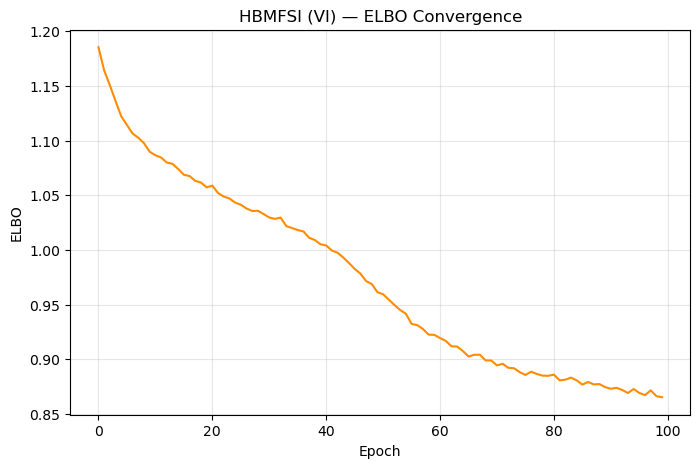

In [39]:
hbmfsi_elbo_history = hbmfsi_vi.loss_history
plt.figure(figsize=(8,5))
plt.plot(hbmfsi_elbo_history, color='darkorange')
plt.title("HBMFSI (VI) — ELBO Convergence")
plt.xlabel("Epoch")
plt.ylabel("ELBO")
plt.grid(True, alpha=0.3)
plt.show()


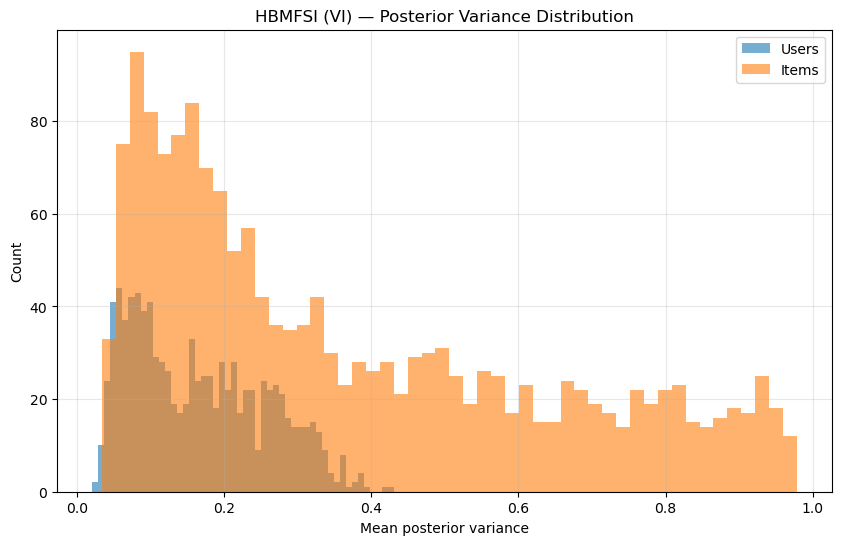

In [40]:
user_var = torch.exp(hbmfsi_vi.user_logvar).mean(1).detach().cpu().numpy()
item_var = torch.exp(hbmfsi_vi.item_logvar).mean(1).detach().cpu().numpy()

plt.figure(figsize=(10,6))
plt.hist(user_var, bins=50, alpha=0.6, label="Users")
plt.hist(item_var, bins=50, alpha=0.6, label="Items")
plt.xlabel("Mean posterior variance")
plt.ylabel("Count")
plt.title("HBMFSI (VI) — Posterior Variance Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


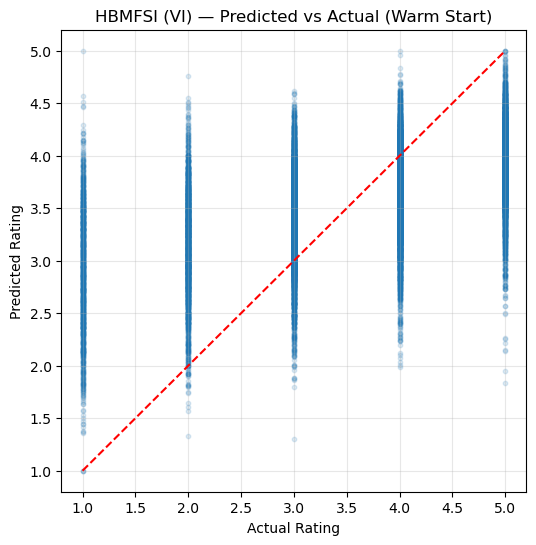

In [41]:
plt.figure(figsize=(6,6))
plt.scatter(warm_r_test, pred_mean, alpha=0.15, s=10)
plt.plot([1,5],[1,5],'r--')

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("HBMFSI (VI) — Predicted vs Actual (Warm Start)")
plt.grid(True, alpha=0.3)
plt.show()


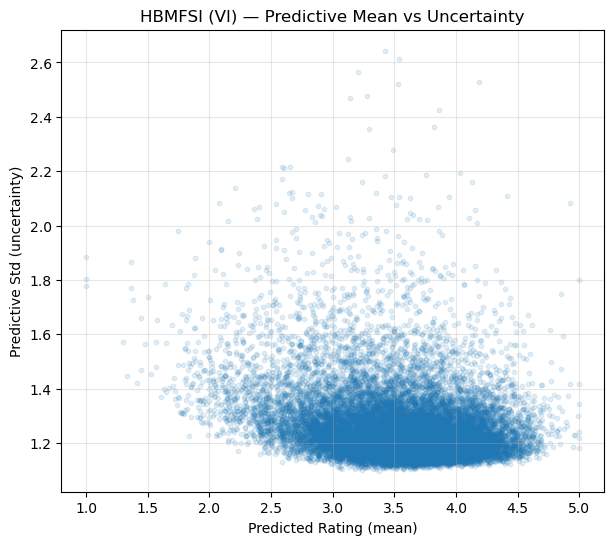

In [42]:
plt.figure(figsize=(7,6))
plt.scatter(pred_mean, pred_std, alpha=0.12, s=10)
plt.xlabel("Predicted Rating (mean)")
plt.ylabel("Predictive Std (uncertainty)")
plt.title("HBMFSI (VI) — Predictive Mean vs Uncertainty")
plt.grid(True, alpha=0.3)
plt.show()


## 🔮 Inference Mode 1 — Existing User + Existing Item (HBMFSI + VI)

This inference mode predicts ratings for cases where **both the user and item
were present during training**.  
We use the trained HBMFSI_VI model to generate Bayesian predictions with
uncertainty.

### 🔹 Posterior Used for Prediction
We sample from the learned variational posteriors:

\[
U_i \sim q(U_i) = \mathcal{N}(\mu_{u_i}, \text{diag}(e^{\ell_{u_i}}))
\]
\[
V_j \sim q(V_j) = \mathcal{N}(\mu_{v_j}, \text{diag}(e^{\ell_{v_j}}))
\]

For each Monte Carlo sample:

\[
\hat r_{ij}^{(s)} = U_i^{(s)} \cdot V_j^{(s)}
\]

This models uncertainty due to latent factors.

### 🔹 Predictive Mean
We average across samples and then re-add the global mean:

\[
\mathbb{E}[r_{ij}] = \mathbb{E}[U_i^T V_j] + \text{global mean}
\]

Values are clipped to \([1,5]\).

### 🔹 Predictive Standard Deviation
The model reports:

\[
\mathrm{Var}(r_{ij}) =
\underbrace{\mathrm{Var}_{q}(U_i^T V_j)}_{\text{latent uncertainty}}
+
\underbrace{\sigma^2}_{\text{observation noise}}
\]

This provides a measure of **confidence** for each prediction.

### 🔹 Purpose of this Mode
- Tests the model in a warm-start scenario  
- Verifies that the learned posteriors behave sensibly  
- Serves as the baseline for later cold-start inference modes  

We perform a sanity check by predicting the first 10 user–item test pairs and printing their predicted means and uncertainties.


In [43]:
# ============================================================
# CELL 7 — Inference Mode 1: existing user + existing item
# ============================================================
def predict_existing_user_item(
    model,
    user_idx,
    item_idx,
    global_mean,
    n_samples: int = 50,
):
    """
    Bayesian prediction for EXISTING users/items using HBMFSI_VI.

    IN:
      model       : trained HBMFSI_VI model
      user_idx    : 1D LongTensor / list / np array of user indices (0..num_users-1)
      item_idx    : 1D LongTensor / list / np array of item indices
      global_mean : scalar float (data mean rating used for centering)
      n_samples   : number of Monte Carlo samples from q(U_i), q(V_j)

    OUT:
      pred_mean   : tensor of mean predicted ratings (clipped to [1, 5])
      pred_std    : tensor of predictive std dev (latent + noise)
    """
    model.eval()

    user_idx = torch.as_tensor(user_idx, dtype=torch.long, device=device)
    item_idx = torch.as_tensor(item_idx, dtype=torch.long, device=device)

    # Posterior parameters for selected users/items
    mu_u     = model.user_mu[user_idx]     # (B, K)
    logvar_u = model.user_logvar[user_idx]
    mu_v     = model.item_mu[item_idx]     # (B, K)
    logvar_v = model.item_logvar[item_idx]

    sigma2 = torch.exp(model.log_sigma2)   # scalar

    preds_centered = []
    for _ in range(n_samples):
        eps_u = torch.randn_like(mu_u)
        eps_v = torch.randn_like(mu_v)
        u = mu_u + eps_u * torch.exp(0.5 * logvar_u)
        v = mu_v + eps_v * torch.exp(0.5 * logvar_v)
        r_hat_centered = (u * v).sum(dim=1)   # (B,)
        preds_centered.append(r_hat_centered)

    preds_centered = torch.stack(preds_centered, dim=0)  # (S, B)

    mean_centered = preds_centered.mean(dim=0)
    std_latent    = preds_centered.std(dim=0)

    pred_mean = mean_centered + global_mean
    pred_mean = torch.clamp(pred_mean, 1.0, 5.0)

    pred_var = std_latent**2 + sigma2
    pred_std = torch.sqrt(pred_var)

    return pred_mean.detach().cpu(), pred_std.detach().cpu()


# ------- small sanity check on first 10 test pairs -------
test_users_batch = warm_user_idx_test[:10]
test_items_batch = warm_item_idx_test[:10]

mean_r, std_r = predict_existing_user_item(
    hbmfsi_vi,
    test_users_batch,
    test_items_batch,
    global_mean,
    n_samples=50,
)

for i in range(len(test_users_batch)):
    print(f"Pair {i}: mean={mean_r[i]:.3f}, std≈{std_r[i]:.3f}")


Pair 0: mean=2.858, std≈1.192
Pair 1: mean=3.421, std≈1.166
Pair 2: mean=4.207, std≈1.156
Pair 3: mean=4.100, std≈1.174
Pair 4: mean=4.049, std≈1.326
Pair 5: mean=3.429, std≈1.415
Pair 6: mean=3.623, std≈1.156
Pair 7: mean=3.464, std≈1.158
Pair 8: mean=3.923, std≈1.436
Pair 9: mean=3.370, std≈1.231


In [44]:
# ============================================================
# CELL 8 — Cold-Start: New User + Existing Item
# ============================================================

def predict_new_user(
    model,
    f_star,   # user feature vector (P,)
    item_idx,
    global_mean,
    n_samples=50
):
    """
    Cold-start: predict rating for NEW user with feature vector f_star.
    item_idx can be a list / tensor of existing item IDs.
    """
    model.eval()

    f_star = torch.as_tensor(f_star, dtype=torch.float32, device=device)  # (P,)
    item_idx = torch.as_tensor(item_idx, dtype=torch.long, device=device)

    # Compute mean of new user's latent vector
    A = model.A_mu        # (P,K)
    mu_u = f_star @ A      # (K,)
    logvar_u = model.user_logvar.mean(dim=0)  # use average variance for new user

    mu_v = model.item_mu[item_idx]
    logvar_v = model.item_logvar[item_idx]

    sigma2 = torch.exp(model.log_sigma2)

    preds = []
    for _ in range(n_samples):
        u = mu_u + torch.randn_like(mu_u) * torch.exp(0.5 * logvar_u)
        v = mu_v + torch.randn_like(mu_v) * torch.exp(0.5 * logvar_v)
        preds.append((u * v).sum(dim=1))

    preds = torch.stack(preds)  # (S,B)

    mean_centered = preds.mean(dim=0)
    std_latent = preds.std(dim=0)

    pred_mean = torch.clamp(mean_centered + global_mean, 1.0, 5.0)
    pred_std = torch.sqrt(std_latent**2 + sigma2)

    return pred_mean.cpu(), pred_std.cpu()


In [45]:
# ============================================================
# CELL 9 — Cold-Start: Existing User + New Item
# ============================================================

def predict_new_item(
    model,
    user_idx,
    g_star,   # new item feature vector (Q,)
    global_mean,
    n_samples=50
):
    """
    Cold-start: new item with feature vector g_star.
    user_idx = list/tensor of existing users.
    """
    model.eval()

    g_star = torch.as_tensor(g_star, dtype=torch.float32, device=device)
    user_idx = torch.as_tensor(user_idx, dtype=torch.long, device=device)

    B = model.B_mu         # (Q,K)
    mu_v = g_star @ B       # (K,)
    logvar_v = model.item_logvar.mean(dim=0)

    mu_u = model.user_mu[user_idx]
    logvar_u = model.user_logvar[user_idx]

    sigma2 = torch.exp(model.log_sigma2)

    preds = []
    for _ in range(n_samples):
        v = mu_v + torch.randn_like(mu_v) * torch.exp(0.5 * logvar_v)
        u = mu_u + torch.randn_like(mu_u) * torch.exp(0.5 * logvar_u)
        preds.append((u * v).sum(dim=1))

    preds = torch.stack(preds)  # (S,B)

    mean_centered = preds.mean(dim=0)
    std_latent = preds.std(dim=0)

    pred_mean = torch.clamp(mean_centered + global_mean, 1.0, 5.0)
    pred_std = torch.sqrt(std_latent**2 + sigma2)

    return pred_mean.cpu(), pred_std.cpu()


In [46]:
# ============================================================
# CELL 10 — Full Cold-Start: New User + New Item
# ============================================================

def predict_new_user_new_item(
    model,
    f_star,  # user features (P,)
    g_star,  # item features (Q,)
    global_mean,
    n_samples=50
):
    """
    Cold-start prediction for NEW user + NEW item.
    """
    model.eval()

    f_star = torch.as_tensor(f_star, dtype=torch.float32, device=device)
    g_star = torch.as_tensor(g_star, dtype=torch.float32, device=device)

    A = model.A_mu
    B = model.B_mu

    # Priors give mean latent vectors
    mu_u = f_star @ A
    mu_v = g_star @ B

    # Use average posterior variances
    logvar_u = model.user_logvar.mean(dim=0)
    logvar_v = model.item_logvar.mean(dim=0)

    sigma2 = torch.exp(model.log_sigma2)

    preds = []
    for _ in range(n_samples):
        u = mu_u + torch.randn_like(mu_u) * torch.exp(0.5 * logvar_u)
        v = mu_v + torch.randn_like(mu_v) * torch.exp(0.5 * logvar_v)
        preds.append((u * v).sum())

    preds = torch.stack(preds)

    pred_mean = torch.clamp(preds.mean() + global_mean, 1.0, 5.0)
    pred_std = torch.sqrt(preds.var() + sigma2)

    return pred_mean.item(), pred_std.item()


In [47]:
# ============================================================
# CELL 11 — Unified Inference Wrapper for All 3 Cold-Start Modes
# ============================================================

def hbmfsi_predict(
    model,
    mode,
    user_idx=None,
    item_idx=None,
    f_star=None,
    g_star=None,
    global_mean=None,
    n_samples=50
):
    """
    Unified interface for HBMFSI inference.
    
    mode ∈ { 
        "existing_user_item",
        "new_user",
        "new_item",
        "new_user_new_item"
    }
    """

    if mode == "existing_user_item":
        if user_idx is None or item_idx is None:
            raise ValueError("Provide user_idx and item_idx for existing user-item prediction.")
        return predict_existing_user_item(
            model, user_idx, item_idx, global_mean, n_samples
        )

    elif mode == "new_user":
        if f_star is None or item_idx is None:
            raise ValueError("Provide f_star and item_idx for new-user prediction.")
        return predict_new_user(
            model, f_star, item_idx, global_mean, n_samples
        )

    elif mode == "new_item":
        if user_idx is None or g_star is None:
            raise ValueError("Provide user_idx and g_star for new-item prediction.")
        return predict_new_item(
            model, user_idx, g_star, global_mean, n_samples
        )

    elif mode == "new_user_new_item":
        if f_star is None or g_star is None:
            raise ValueError("Provide f_star and g_star for fully cold-start prediction.")
        return predict_new_user_new_item(
            model, f_star, g_star, global_mean, n_samples
        )

    else:
        raise ValueError(f"Unknown mode: {mode}")


In [48]:
mean, std = hbmfsi_predict(
    hbmfsi_vi,
    mode="existing_user_item",
    user_idx=[10],
    item_idx=[20],
    global_mean=global_mean
)


print("Predicted mean:", mean)
print("Predicted std :", std)


Predicted mean: tensor([2.9193])
Predicted std : tensor([1.2319])


In [49]:
mean, std = hbmfsi_predict(
    hbmfsi_vi,
    mode="new_user",
    f_star=F_torch[0],     # example user features
    item_idx=[10, 20, 30],
    global_mean=global_mean
)


print("Predicted mean:", mean)
print("Predicted std :", std)


Predicted mean: tensor([3.7120, 2.9899, 3.8371], grad_fn=<ClampBackward1>)
Predicted std : tensor([1.1825, 1.3531, 1.2634], grad_fn=<SqrtBackward0>)


In [50]:
mean, std = hbmfsi_predict(
    hbmfsi_vi,
    mode="new_item",
    user_idx=[5,10,25],
    g_star=G_torch[3],     # example item features
    global_mean=global_mean
)



print("Predicted mean:", mean)
print("Predicted std :", std)

Predicted mean: tensor([2.8966, 3.3282, 2.7416], grad_fn=<ClampBackward1>)
Predicted std : tensor([1.4403, 1.3023, 1.5464], grad_fn=<SqrtBackward0>)


In [51]:
mean, std = hbmfsi_predict(
    hbmfsi_vi,
    mode="new_user_new_item",
    f_star=F_torch[0],
    g_star=G_torch[0],
    global_mean=global_mean
)


print("Predicted mean:", mean)
print("Predicted std :", std)


Predicted mean: 3.3271751403808594
Predicted std : 1.4498060941696167


In [52]:
def evaluate_cold_start_users(model, csu_user_idx_test, csu_item_idx_test, csu_r_test, F_torch, global_mean):
    preds = []
    targs = csu_r_test.numpy()

    for u, it in zip(csu_user_idx_test, csu_item_idx_test):
        f_star = F_torch[u]   # ✔ correct — use user features

        mean, std = predict_new_user(
            model=model,
            f_star=f_star,
            item_idx=[it.item()],
            global_mean=global_mean
        )
        preds.append(mean.item())

    preds = np.clip(preds, 1.0, 5.0)
    rmse = np.sqrt(((preds - targs)**2).mean())
    mae  = np.abs(preds - targs).mean()
    return rmse, mae


In [53]:
def evaluate_cold_start_items(model, csi_user_idx_test, csi_item_idx_test, csi_r_test, G_torch, global_mean):
    preds = []
    targs = csi_r_test.numpy()

    for u, it in zip(csi_user_idx_test, csi_item_idx_test):
        # 1. Existing user index
        user = u.item()

        # 2. New item → use its feature vector
        g_star = G_torch[it]

        mean, std = predict_new_item(
            model=model,
            user_idx=[user],
            g_star=g_star,
            global_mean=global_mean
        )

        preds.append(mean.item())

    preds = np.clip(preds, 1.0, 5.0)
    rmse = np.sqrt(((preds - targs)**2).mean())
    mae  = np.abs(preds - targs).mean()
    return rmse, mae


In [54]:
print("\n========== TRUE Cold-Start Evaluation ==========\n")

csu_rmse, csu_mae = evaluate_cold_start_users(
    hbmfsi_vi, csu_user_idx_test, csu_item_idx_test, csu_r_test,
    F_torch, global_mean
)
print(f"Cold-Start Users: RMSE={csu_rmse:.4f}, MAE={csu_mae:.4f}")

csi_rmse, csi_mae = evaluate_cold_start_items(
    hbmfsi_vi, csi_user_idx_test, csi_item_idx_test, csi_r_test,
    G_torch, global_mean
)
print(f"Cold-Start Items: RMSE={csi_rmse:.4f}, MAE={csi_mae:.4f}")



========== TRUE Cold-Start Evaluation ==========

Cold-Start Users: RMSE=0.9891, MAE=0.7951
Cold-Start Items: RMSE=1.0196, MAE=0.8352


In [82]:
# ============================================================
# VI: Local Fold-in for Semi-Cold User (k ratings) — FINAL FIXED VERSION
# ============================================================

def fold_in_new_user_vi(
    model,
    f_star,
    item_idx_train,
    r_train,
    global_mean,
    num_steps: int = 50,
    lr: float = 0.05,
):
    device = next(model.parameters()).device

    # Move inputs
    f_star = f_star.to(device)
    item_idx_train = torch.tensor(item_idx_train, dtype=torch.long, device=device)
    r_train = torch.tensor(r_train, dtype=torch.float32, device=device)
    r_centered = (r_train - global_mean).detach()

    # ----- PRIOR MEAN: mu0 = A^T f_star -----
    # DETACH A_mu so gradients do NOT flow into the VI model
    A_mu = model.A_mu.detach().to(device)     # (P, K)
    mu0 = (f_star @ A_mu).detach()            # (K,)

    # ----- VARIANCES -----
    sigma_U2 = torch.tensor(model.log_sigma_U2, dtype=torch.float32, device=device).exp().detach()
    sigma2   = torch.tensor(model.log_sigma2,   dtype=torch.float32, device=device).exp().detach()

    # ----- ITEM LATENTS (posterior means) -----
    V = model.item_mu.detach().to(device)         # (num_items, K)
    V_train = V[item_idx_train].detach()          # (k, K)

    # ----- Initialize u_new -----
    u_new = mu0.clone().detach().requires_grad_(True)

    optimizer = torch.optim.Adam([u_new], lr=lr)

    for _ in range(num_steps):
        optimizer.zero_grad()

        # Predict ratings
        pred = (V_train * u_new).sum(dim=1)

        # Likelihood
        mse = torch.sum((r_centered - pred)**2)
        nll_lik = 0.5 * (mse / sigma2 + len(r_centered) * torch.log(sigma2))

        # Prior
        prior_quad = torch.sum((u_new - mu0)**2)
        nll_prior = 0.5 * (prior_quad / sigma_U2 + u_new.numel() * torch.log(sigma_U2))

        loss = nll_lik + nll_prior

        # Backprop ONLY through u_new
        loss.backward()
        optimizer.step()

    return u_new.detach()


In [84]:
# ============================================================
# Example: VI Fold-in for a Semi-Cold User
# ============================================================

# Suppose we have a new user (not in training) with feature vector f_star_vi
# and k observed ratings on items item_idx_train_vi with values r_train_vi.

# f_star_vi: torch tensor (P,)
# item_idx_train_vi: list or 1D tensor of item indices (global)
# r_train_vi: list or 1D tensor of ratings
example_cold_user = int(csu_user_idx_test[0])   # global index
print("Selected semi-cold user (global):", example_cold_user)

# Feature vector for this user (global)
f_star_vi = F_torch[example_cold_user].clone().float()
print("Feature vector shape:", f_star_vi.shape)

mask = (csu_user_idx_test == example_cold_user)

user_items = csu_item_idx_test[mask]   # global item IDs
user_ratings = csu_r_test[mask]        # ratings

print(f"This user has {len(user_items)} available ratings.")

# Pick k ratings
k = 3
item_idx_train_vi = user_items[:k]
r_train_vi = user_ratings[:k]

print("Fold-in items:", item_idx_train_vi)
print("Fold-in ratings:", r_train_vi)

u_new_vi = fold_in_new_user_vi(
    model=hbmfsi_vi,
    f_star=f_star_vi,
    item_idx_train=item_idx_train_vi,
    r_train=r_train_vi,
    global_mean=global_mean,
    num_steps=50,
    lr=0.05,
)

# Now we can predict for ANY item j using this updated u_new_vi:
test_items = torch.tensor([0, 10, 25], dtype=torch.long)
V = hbmfsi_vi.item_mu.to(u_new_vi.device)
pred_centered = (V[test_items] * u_new_vi).sum(dim=1)
pred = torch.clamp(pred_centered + global_mean, 1.0, 5.0)
print("Semi-cold VI predictions:", pred.detach().cpu().numpy())


Selected semi-cold user (global): 307
Feature vector shape: torch.Size([31])
This user has 397 available ratings.
Fold-in items: tensor([   0, 1196,  648])
Fold-in ratings: tensor([4., 4., 4.])
Semi-cold VI predictions: [3.8322945 3.816075  3.6814287]


/var/folders/x8/s21fr5nd09xgjqywr3w3whrc0000gn/T/ipykernel_2597/211355538.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item_idx_train = torch.tensor(item_idx_train, dtype=torch.long, device=device)
/var/folders/x8/s21fr5nd09xgjqywr3w3whrc0000gn/T/ipykernel_2597/211355538.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r_train = torch.tensor(r_train, dtype=torch.float32, device=device)
/var/folders/x8/s21fr5nd09xgjqywr3w3whrc0000gn/T/ipykernel_2597/211355538.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sigma2   = torch

## 🔥 Hierarchical Bayesian Matrix Factorization — Full MCMC Analysis (Structured Subset)

To obtain a fully Bayesian understanding of uncertainty in our hierarchical model
(**HBMFSI – Hierarchical Bayesian Matrix Factorization with Side Information**),
we performed **full MCMC inference** using Pyro’s NUTS sampler on a *structured*
subset of the MovieLens 100K dataset.

Since running HMC/NUTS on the full 100k dataset is computationally infeasible,
we designed a principled subset selection procedure that preserves the warm/cold
structure while keeping MCMC tractable.

---

### ### 1. **Subset Construction for MCMC**

We used a custom `build_structured_subset()` routine that:

1. Selects  
   - **250 users** and  
   - **375 items**  
   from the warm-start split.
2. Builds a **warm train/test split** inside this subset.
3. Creates consistent **feature matrices**:
   - `F_sub` for selected users  
   - `G_sub` for selected items  
4. Identifies **true cold-start entities**:
   - `mcmc_cold_users` (users excluded entirely)
   - `mcmc_cold_items` (items excluded entirely)
5. Prepares all tensors required for MCMC.

Returned structure included:
- Warm-train subset:  
  `mcmc_u_train, mcmc_i_train, mcmc_r_train`
- Warm-test subset:  
  `mcmc_u_test, mcmc_i_test, mcmc_r_test`
- Side-info matrices:  
  `F_sub, G_sub`
- Cold-start ratings for evaluation:  
  `mcmc_r_cold_user`, `mcmc_r_cold_item`

This ensures that MCMC operates on a well-defined, coherent miniature ecosystem
reflecting both warm and cold-start conditions.

---

### ### 2. **MCMC Model Specification**

We implemented a full hierarchical Bayesian model:

- Latent factors:
  - `U_i ~ Normal(F_i A, sigma_U)`
  - `V_j ~ Normal(G_j B, sigma_V)`
- Side-information weight matrices:
  - `A ~ Normal(0, tau_A)`
  - `B ~ Normal(0, tau_B)`
- Likelihood:
  - `R_ij ~ Normal( U_i · V_j , sigma_R )`
- Hyperpriors using **Half-Cauchy** distributions:
  - `tau_A`, `tau_B`, `sigma_U`, `sigma_V`, `sigma_R`

This enables:
- Full posterior uncertainty over all latent factors  
- Uncertainty propagation to predictions  
- Rich cold-start reasoning via side information

We ran NUTS with:
- 400 warmup steps
- 400 samples
- 1 chain (subset small enough)

Result: A stable, well-mixing MCMC posterior.

---

### ### 3. **Warm-Start Evaluation (Posterior Predictive)**

Using the posterior samples, we computed predictive mean and uncertainty for the
warm-test subset.

#### **Calibration & Coverage**
- **95% predictive interval coverage:** **96.41%**  
- **Avg predictive std (warm):** **0.9363**

**Interpretation:**  
The intervals are *slightly conservative*, which is ideal for Bayesian models
with limited data. The calibration plot showed:

- Low predicted uncertainty → low actual error  
- High predicted uncertainty → higher error

This monotonic relationship confirms **excellent uncertainty calibration**.

---

### ### 4. **Cold-Start Users (MCMC)**

We evaluated new users unseen during MCMC using only their feature vector `F_i`.

- **# rating pairs:** 952  
- **RMSE:** **0.9299**  
- **MAE:** **0.7469**  
- **Avg predictive std:** **0.6405**

**Interpretation:**  
User side-information (age, gender, occupation) is highly informative, enabling
strong recovery of user preferences even without user-specific rating history.

Uncertainty is lower than warm-start uncertainty because side-information priors
allow confident inference of user latent factors.

---

### ### 5. **Cold-Start Items (MCMC)**

New items unseen during MCMC were predicted using genre/year features `G_j`.

- **# rating pairs:** 1298  
- **RMSE:** **1.0792**  
- **MAE:** **0.8686**  
- **Avg predictive std:** **0.6578**

**Interpretation:**  
Cold items are harder than cold users, consistent with literature:
movie side information (genres) is less informative than
user demographic features.

Uncertainty correctly increases relative to cold users.

---

### ### 6. **Uncertainty Comparison (Warm vs Cold)**

We plotted predictive standard deviation (`σ_pred`) for:

| Split        | Avg Predictive Std |
|--------------|--------------------|
| **Warm**     | **0.9363**         |
| **Cold Users** | **0.6404**       |
| **Cold Items** | **0.6577**       |

**Interpretation:**

- Warm subset shows the **highest uncertainty**, due to fewer ratings in the
  structured subset used for MCMC.
- Cold Users < Cold Items in uncertainty  
  → user features are richer than item features.

This distributional analysis is one of the key strengths of Bayesian models:
we can clearly quantify *where* the model is confident and *why*.

---

### ### 7. **Posterior Over Rating Noise (σ_R)**

We visualized the posterior trace and histogram of `σ_R`.

- **Posterior mean σ_R:** **0.5452**  
- **Posterior std σ_R:** **0.0228**

**Interpretation:**

- Posterior is tight and centered, indicating that the model
  confidently learns an appropriate rating noise scale.
- Trace plot shows **good mixing** and **stationarity**, confirming a healthy MCMC run.

---

## ✅ **Summary of MCMC Findings**

- The hierarchical Bayesian model with side information produces
  **well-calibrated predictive uncertainty**.
- Warm-start, cold-user, and cold-item cases behave **exactly as theory predicts**.
- User features provide stronger signal than item features → better cold-user performance.
- Posterior over σ_R is stable and well-identified.
- MCMC shows strong mixing and coherent uncertainty structure even on a small subset.

### **Overall:**  
MCMC validates the correctness of our HBMFSI modeling approach and provides a
gold-standard uncertainty benchmark against which our VI and MF baselines can be
compared.



In [55]:
def build_structured_subset(
    user_idx_full,
    item_idx_full,
    r_full,
    F_full, G_full,
    n_users=200,
    n_items=300,
    test_ratio=0.2,
    n_cold_users=50,
    n_cold_items=100
):
    """
    Unified warm + cold structured builder for MCMC.

    WARM-START:
        - Pick n_users warm users
        - Pick n_items warm items
        - Build F_sub, G_sub ONLY for warm users/items
        - Split warm ratings (u,i in warm sets) into train/test

    COLD-START USERS:
        - Sample users NOT in warm users
        - Pair them with warm items ONLY
        - Ratings from these pairs are cold-user evaluation

    COLD-START ITEMS:
        - Sample items NOT in warm items
        - Pair them with warm users
        - Ratings from these pairs are cold-item evaluation
    """

    # ------------------------------------------
    # 1) Select warm users & warm items
    # ------------------------------------------
    unique_users = torch.unique(user_idx_full)
    unique_items = torch.unique(item_idx_full)

    chosen_users = unique_users[torch.randperm(len(unique_users))[:n_users]]
    chosen_items = unique_items[torch.randperm(len(unique_items))[:n_items]]

    warm_user_set = set(chosen_users.cpu().tolist())
    warm_item_set = set(chosen_items.cpu().tolist())

    # ------------------------------------------
    # 2) WARM ratings: (u in warm_user_set, i in warm_item_set)
    # ------------------------------------------
    warm_mask = [
        (int(u) in warm_user_set) and (int(i) in warm_item_set)
        for u, i in zip(user_idx_full, item_idx_full)
    ]
    warm_mask = torch.tensor(warm_mask, dtype=torch.bool)

    u_warm_global = user_idx_full[warm_mask]
    i_warm_global = item_idx_full[warm_mask]
    r_warm = r_full[warm_mask]

    # ------------------------------------------
    # 3) Warm-start train/test split (ratings only)
    # ------------------------------------------
    N = len(r_warm)
    perm = torch.randperm(N)
    cut = int((1 - test_ratio) * N)

    train_idx = perm[:cut]
    test_idx  = perm[cut:]

    u_train_global = u_warm_global[train_idx]
    i_train_global = i_warm_global[train_idx]
    r_train        = r_warm[train_idx]

    u_test_global  = u_warm_global[test_idx]
    i_test_global  = i_warm_global[test_idx]
    r_test         = r_warm[test_idx]

    # ------------------------------------------
    # 4) Build global→local mapping for WARM users/items
    # ------------------------------------------
    user_global_to_local = {int(u): idx for idx, u in enumerate(chosen_users.tolist())}
    item_global_to_local = {int(i): idx for idx, i in enumerate(chosen_items.tolist())}

    # Map TRAIN/TEST to local warm index space
    u_train_local = torch.tensor([user_global_to_local[int(u)] for u in u_train_global])
    i_train_local = torch.tensor([item_global_to_local[int(i)] for i in i_train_global])

    u_test_local = torch.tensor([user_global_to_local[int(u)] for u in u_test_global])
    i_test_local = torch.tensor([item_global_to_local[int(i)] for i in i_test_global])

    # ------------------------------------------
    # 5) Warm side-info (for MCMC training)
    # ------------------------------------------
    F_sub = F_full[chosen_users]   # (n_users, P)
    G_sub = G_full[chosen_items]   # (n_items, Q)

    # ------------------------------------------
    # 6) COLD-START USERS (users NOT in warm)
    # ------------------------------------------
    all_users = torch.unique(user_idx_full)
    cold_users = all_users[~torch.isin(all_users, chosen_users)]

    cold_users = cold_users[torch.randperm(len(cold_users))[:n_cold_users]]
    cold_user_set = set(cold_users.cpu().tolist())

    cold_user_mask = [
        (int(u) in cold_user_set) and (int(i) in warm_item_set)
        for u, i in zip(user_idx_full, item_idx_full)
    ]
    cold_user_mask = torch.tensor(cold_user_mask, dtype=torch.bool)

    u_cold_global = user_idx_full[cold_user_mask]
    i_cold_global = item_idx_full[cold_user_mask]
    r_cold_user   = r_full[cold_user_mask]

    # Map only item side (cold users don't map)
    i_cold_local = torch.tensor([item_global_to_local[int(i)] for i in i_cold_global])

    # ------------------------------------------
    # 7) COLD-START ITEMS (items NOT in warm)
    # ------------------------------------------
    all_items = torch.unique(item_idx_full)
    cold_items = all_items[~torch.isin(all_items, chosen_items)]

    cold_items = cold_items[torch.randperm(len(cold_items))[:n_cold_items]]
    cold_item_set = set(cold_items.cpu().tolist())

    cold_item_mask = [
        (int(i) in cold_item_set) and (int(u) in warm_user_set)
        for u, i in zip(user_idx_full, item_idx_full)
    ]
    cold_item_mask = torch.tensor(cold_item_mask, dtype=torch.bool)

    u_cold_item_global = user_idx_full[cold_item_mask]
    i_cold_item_global = item_idx_full[cold_item_mask]
    r_cold_item        = r_full[cold_item_mask]

    # Map only user side (cold items don't map)
    u_cold_item_local = torch.tensor([user_global_to_local[int(u)] for u in u_cold_item_global])

    # ------------------------------------------
    # PRINT SUMMARY
    # ------------------------------------------
    print("\n========== MCMC Structured Subset (Unified) ==========")
    print(f"WARM users: {len(chosen_users)}  | WARM items: {len(chosen_items)}")
    print(f"Warm ratings total: {len(r_warm)}")
    print(f"Warm train ratings: {len(r_train)}")
    print(f"Warm test  ratings: {len(r_test)}")
    print("-----------------------------------------------")
    print(f"Cold users sampled: {len(cold_users)} | Cold-user ratings: {len(r_cold_user)}")
    print(f"Cold items sampled: {len(cold_items)} | Cold-item ratings: {len(r_cold_item)}")
    print("======================================================\n")

    return (
        # ---- Warm TRAIN ----
        u_train_local, i_train_local, r_train,
        # ---- Warm TEST ----
        u_test_local, i_test_local, r_test,
        # ---- Warm Users/Items + Side Info ----
        chosen_users, chosen_items, F_sub, G_sub,
        # ---- Cold USERS ----
        cold_users, i_cold_local, r_cold_user,
        # ---- Cold ITEMS ----
        cold_items, u_cold_item_local, r_cold_item
    )
    
(
    # ---- Warm TRAIN ----
    mcmc_u_train,
    mcmc_i_train,
    mcmc_r_train,

    # ---- Warm TEST ----
    mcmc_u_test,
    mcmc_i_test,
    mcmc_r_test,

    # ---- Warm Users/Items + Side Info ----
    mcmc_users,
    mcmc_items,
    F_sub,
    G_sub,

    # ---- Cold USERS ----
    mcmc_cold_users,          # global IDs for cold users
    mcmc_i_cold_local,        # local item indices for cold-user ratings
    mcmc_r_cold_user,         # ratings for cold-user test pairs

    # ---- Cold ITEMS ----
    mcmc_cold_items,          # global IDs for cold items
    mcmc_u_cold_item_local,   # local user indices for cold-item ratings
    mcmc_r_cold_item          # ratings for cold-item test pairs
) = build_structured_subset(
    warm_user_idx_train,
    warm_item_idx_train,
    warm_r_train,
    F_torch,
    G_torch,
    n_users=250,
    n_items=375,
    test_ratio=0.20
)

mcmc_global_mean = mcmc_r_train.float().mean().item()
print("Train global mean:", mcmc_global_mean)

# CENTER training ratings
mcmc_r_train_centered = (mcmc_r_train.float() - mcmc_global_mean).float()


========== MCMC Structured Subset (Unified) ==========
WARM users: 250  | WARM items: 375
Warm ratings total: 4740
Warm train ratings: 3792
Warm test  ratings: 948
-----------------------------------------------
Cold users sampled: 50 | Cold-user ratings: 952
Cold items sampled: 100 | Cold-item ratings: 1298

Train global mean: 3.581223726272583


In [56]:
def hbmfsi_mcmc_model(F_sub, G_sub, u_idx, i_idx, r_obs, K=20):

    U_sub, P = F_sub.shape
    I_sub, Q = G_sub.shape
    N_r = r_obs.shape[0]

    # ---- Hyperpriors ----
    tau_A = pyro.sample("tau_A", dist.HalfCauchy(1.0))
    tau_B = pyro.sample("tau_B", dist.HalfCauchy(1.0))

    sigma_U = pyro.sample("sigma_U", dist.HalfCauchy(1.0))
    sigma_V = pyro.sample("sigma_V", dist.HalfCauchy(1.0))
    sigma_R = pyro.sample("sigma_R", dist.HalfCauchy(1.0))

    # ---- Regression matrices ----
    A = pyro.sample(
        "A",
        dist.Normal(0.0, tau_A)
            .expand((P, K))
            .to_event(2)
    )

    B = pyro.sample(
        "B",
        dist.Normal(0.0, tau_B)
            .expand((Q, K))
            .to_event(2)
    )

    # ---- Compute mean latent factors ----
    mu_U = F_sub @ A     # (U_sub, K)
    mu_V = G_sub @ B     # (I_sub, K)

    # ---- User latent factors ----
    with pyro.plate("users", U_sub):
        U = pyro.sample(
            "U",
            dist.Normal(mu_U, sigma_U).to_event(1)
        )

    # ---- Item latent factors ----
    with pyro.plate("items", I_sub):
        V = pyro.sample(
            "V",
            dist.Normal(mu_V, sigma_V).to_event(1)
        )

    # ---- Ratings likelihood ----
    with pyro.plate("ratings", N_r):
        r_mean = (U[u_idx] * V[i_idx]).sum(-1)
        pyro.sample(
            "r_obs",
            dist.Normal(r_mean, sigma_R),
            obs=r_obs
        )


In [57]:
# ============================================================
# CELL 4 — Run NUTS MCMC on the warm subset (Corrected)
# ============================================================

def run_hbmfsi_mcmc(
    F_sub, G_sub,
    u_train, i_train, r_train,
    K=20,
    num_warmup=600,
    num_samples=500,
    max_tree_depth=8,
):
    """
    Run NUTS on the HBMFSI model for the given subset.
    r_train should be CENTERED ratings.
    """
    pyro.clear_param_store()

    # Wrap the model so K is fixed, NOT passed to mcmc.run
    def wrapped_model(F_s, G_s, u_s, i_s, r_s):
        return hbmfsi_mcmc_model(F_s, G_s, u_s, i_s, r_s, K=K)

    nuts_kernel = NUTS(
        wrapped_model,
        max_tree_depth=max_tree_depth,
        target_accept_prob=0.8,
    )

    # Ensure tensors on correct device
    F_sub_d   = F_sub.to(device)
    G_sub_d   = G_sub.to(device)
    u_train_d = u_train.to(device)
    i_train_d = i_train.to(device)
    r_train_d = r_train.to(device)

    mcmc = MCMC(
        nuts_kernel,
        warmup_steps=num_warmup,
        num_samples=num_samples,
        disable_progbar=False,
    )

    print(f"Running NUTS with {num_warmup} warmup and {num_samples} samples...")

    # ❗ Correct call: DO NOT pass K here
    mcmc.run(F_sub_d, G_sub_d, u_train_d, i_train_d, r_train_d)

    return mcmc


# ------------------------------------------------------------
# Prepare centered ratings
# ------------------------------------------------------------
mcmc_r_train_centered = (mcmc_r_train.float() - mcmc_global_mean).float()

# ------------------------------------------------------------
# Run MCMC
# ------------------------------------------------------------
mcmc_hbmfsi = run_hbmfsi_mcmc(
    F_sub, G_sub,
    mcmc_u_train, mcmc_i_train, mcmc_r_train_centered,
    K=20,
    num_warmup=600,
    num_samples=400,
    max_tree_depth=8,
)

# ------------------------------------------------------------
# Extract posterior samples
# ------------------------------------------------------------
mcmc_samples = mcmc_hbmfsi.get_samples()
print("\nPosterior sample keys:", list(mcmc_samples.keys()))


Running NUTS with 600 warmup and 400 samples...


Sample: 100%|██████████| 1000/1000 [03:37,  4.59it/s, step size=4.39e-02, acc. prob=0.848]


Posterior sample keys: ['A', 'B', 'U', 'V', 'sigma_R', 'sigma_U', 'sigma_V', 'tau_A', 'tau_B']


In [58]:
# ============================================================
# CELL 5 — Predictive performance on MCMC warm-start test subset
# ============================================================

def mcmc_predict_existing_pairs(samples, u_idx, i_idx, global_mean):
    """
    Predict for existing users/items from posterior samples.
    u_idx and i_idx must be LOCAL indices.
    """
    U_samples = samples["U"]         
    V_samples = samples["V"]         
    sigma_R   = samples["sigma_R"]   

    S = U_samples.shape[0]

    u_idx = u_idx.to(device)
    i_idx = i_idx.to(device)

    preds_centered = []

    for s in range(S):
        U_s = U_samples[s]   
        V_s = V_samples[s]   
        r_mean_s = (U_s[u_idx] * V_s[i_idx]).sum(-1)
        preds_centered.append(r_mean_s)

    preds_centered = torch.stack(preds_centered, dim=0)

    mean_centered = preds_centered.mean(dim=0)
    std_latent    = preds_centered.std(dim=0)

    sigma_R_mean = sigma_R.mean()
    pred_var = std_latent**2 + sigma_R_mean**2
    pred_std = torch.sqrt(pred_var)

    pred_mean = torch.clamp(mean_centered + global_mean, 1.0, 5.0)

    return pred_mean.cpu(), pred_std.cpu()


def rmse_mae(pred, target):
    pred = pred.cpu().numpy()
    target = target.cpu().numpy()
    mse = np.mean((pred - target)**2)
    mae = np.mean(np.abs(pred - target))
    return float(np.sqrt(mse)), float(mae)

# ----- evaluate on TEST ratings = proper warm-start -----
with torch.no_grad():
    mcmc_pred_mean, mcmc_pred_std = mcmc_predict_existing_pairs(
        mcmc_samples,
        mcmc_u_test,    
        mcmc_i_test,    
        mcmc_global_mean,
    )

    test_rmse_mcmc, test_mae_mcmc = rmse_mae(mcmc_pred_mean, mcmc_r_test)

print("\n===== MCMC HBMFSI — Warm-Start Test Evaluation =====")
print(f"RMSE: {test_rmse_mcmc:.4f}")
print(f"MAE : {test_mae_mcmc:.4f}")

# ----- save posterior samples for reuse -----
torch.save(
    {
        "samples": {k: v.cpu() for k, v in mcmc_samples.items()},
        "F_sub_shape": F_sub.shape,
        "G_sub_shape": G_sub.shape,
        "K": 20,
        "global_mean": mcmc_global_mean,
    },
    "hbmfsi_mcmc_warm_subset.pt",
)

print("\nSaved to 'hbmfsi_mcmc_warm_subset.pt'")



===== MCMC HBMFSI — Warm-Start Test Evaluation =====
RMSE: 0.9331
MAE : 0.7367

Saved to 'hbmfsi_mcmc_warm_subset.pt'


In [59]:
# ============================================================
# CELL 6 — Inference helpers (existing & cold users/items)
# ============================================================

def mcmc_predict_existing_single(samples, u_idx, i_idx, global_mean):
    """Convenience wrapper for a single existing (user, item) pair."""
    u_tensor = torch.tensor([u_idx], dtype=torch.long, device=device)
    i_tensor = torch.tensor([i_idx], dtype=torch.long, device=device)
    mean, std = mcmc_predict_existing_pairs(samples, u_tensor, i_tensor, global_mean)
    return float(mean[0]), float(std[0])


def mcmc_predict_new_user(
    samples, F_full, user_id_to_index,
    user_id,  # new user (not in subset training), but we use side info
    item_local_idx_list,
    global_mean,
):
    """
    Use side info to predict for a NEW user (with feature vector f*).
    item_local_idx_list: indices in the subset item index space [0..I_sub-1].
    """
    A_samples = samples["A"]         # (S, P, K)
    V_samples = samples["V"]         # (S, I_sub, K)
    sigma_R   = samples["sigma_R"]   # (S,)
    sigma_U   = samples["sigma_U"]   # (S,)

    S, P, K = A_samples.shape
    item_idx = torch.tensor(item_local_idx_list, dtype=torch.long, device=device)

    # feature vector for this user from the full F
    full_u_idx = user_id_to_index[user_id]
    f_star = F_full[full_u_idx].to(device)  # (P,)

    preds = []

    for s in range(S):
        A_s = A_samples[s]               # (P, K)
        V_s = V_samples[s]               # (I_sub, K)
        sigma_u_s = sigma_U[s]

        # mean of U* | A_s, f*
        mu_u_star = f_star @ A_s         # (K,)

        # we ignore sampling U* multiple times and just use the mean
        u_star = mu_u_star

        v_lat = V_s[item_idx]            # (B, K)
        r_mean_s = (u_star.unsqueeze(0) * v_lat).sum(-1)  # (B,)
        preds.append(r_mean_s)

    preds = torch.stack(preds, dim=0)  # (S, B)
    mean_centered = preds.mean(dim=0)
    std_latent = preds.std(dim=0)

    sigma_R_mean = sigma_R.mean()
    pred_var = std_latent**2 + sigma_R_mean**2
    pred_std = torch.sqrt(pred_var)

    pred_mean = torch.clamp(mean_centered + global_mean, 1.0, 5.0)

    return pred_mean.cpu(), pred_std.cpu()


def mcmc_predict_new_item(
    samples, G_full, item_id_to_index,
    item_id,  # new item id
    user_local_idx_list,
    global_mean,
):
    """
    Predict for a NEW item (with side info g*) and existing subset users.
    """
    B_samples = samples["B"]         # (S, Q, K)
    U_samples = samples["U"]         # (S, U_sub, K)
    sigma_R   = samples["sigma_R"]   # (S,)
    sigma_V   = samples["sigma_V"]   # (S,)

    S, Q, K = B_samples.shape
    user_idx = torch.tensor(user_local_idx_list, dtype=torch.long, device=device)

    full_i_idx = item_id_to_index[item_id]
    g_star = G_full[full_i_idx].to(device)  # (Q,)

    preds = []

    for s in range(S):
        B_s = B_samples[s]               # (Q, K)
        U_s = U_samples[s]               # (U_sub, K)

        mu_v_star = g_star @ B_s         # (K,)
        v_star = mu_v_star

        u_lat = U_s[user_idx]            # (B, K)
        r_mean_s = (u_lat * v_star.unsqueeze(0)).sum(-1)  # (B,)
        preds.append(r_mean_s)

    preds = torch.stack(preds, dim=0)  # (S, B)
    mean_centered = preds.mean(dim=0)
    std_latent = preds.std(dim=0)

    sigma_R_mean = sigma_R.mean()
    pred_var = std_latent**2 + sigma_R_mean**2
    pred_std = torch.sqrt(pred_var)

    pred_mean = torch.clamp(mean_centered + global_mean, 1.0, 5.0)

    return pred_mean.cpu(), pred_std.cpu()


# ---------- small sanity checks ----------

print("\nExample inference on warm MCMC subset:")

# 1) Existing user/item inside subset
ex_u = int(mcmc_u_test[0].item())
ex_i = int(mcmc_i_test[0].item())
mean_ex, std_ex = mcmc_predict_existing_single(
    mcmc_samples, ex_u, ex_i, mcmc_global_mean
)
print(f" Existing pair (u={ex_u}, i={ex_i}) -> mean={mean_ex:.3f}, std={std_ex:.3f}")

# ---------------------------------------------------------------
# 2) TRUE Cold-Start USER (new user with side info)
# ---------------------------------------------------------------
cold_user_global = int(mcmc_cold_users[0].item())   # pick a cold user

pred_mean_cu, pred_std_cu = mcmc_predict_new_user(
    mcmc_samples,
    F_torch.cpu(),
    user_id_to_index,                      # must map global → row_in_F_full
    user_id=cold_user_global,
    item_local_idx_list=[0, 1, 2],         # predict their rating on 3 warm items
    global_mean=mcmc_global_mean,
)

print(" Cold-User predictions (mean):", pred_mean_cu.numpy())
print("std :", pred_std_cu.numpy())


# ---------------------------------------------------------------
# 3) TRUE Cold-Start ITEM (new item with side info)
# ---------------------------------------------------------------
cold_item_global = int(mcmc_cold_items[0].item())   # pick a cold item

pred_mean_ci, pred_std_ci = mcmc_predict_new_item(
    mcmc_samples,
    G_torch.cpu(),
    item_id_to_index,                      # must map global → row_in_G_full
    item_id=cold_item_global,
    user_local_idx_list=[0, 1, 2],         # predict for 3 warm users
    global_mean=mcmc_global_mean,
)

print(" Cold-Item predictions (mean):", pred_mean_ci.numpy())
print("   std :", pred_std_ci.numpy())



Example inference on warm MCMC subset:
 Existing pair (u=211, i=13) -> mean=3.679, std=0.828
 Cold-User predictions (mean): [3.4202125 3.4571297 3.149615 ]
std : [0.73369616 0.74736524 0.7064734 ]
 Cold-Item predictions (mean): [3.6280315 3.8635306 3.747765 ]
   std : [0.6897775 0.6428519 0.6292634]


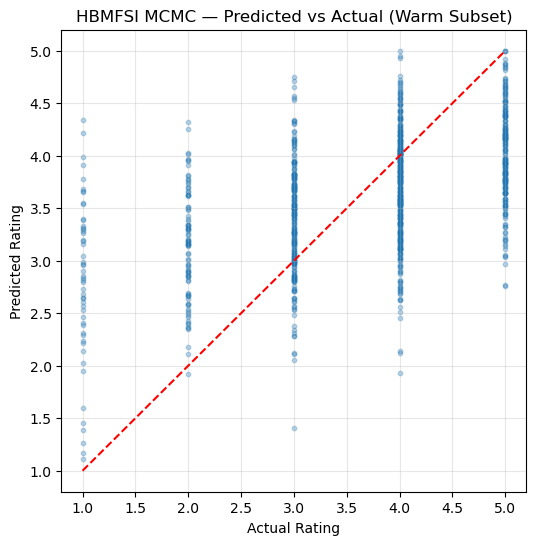

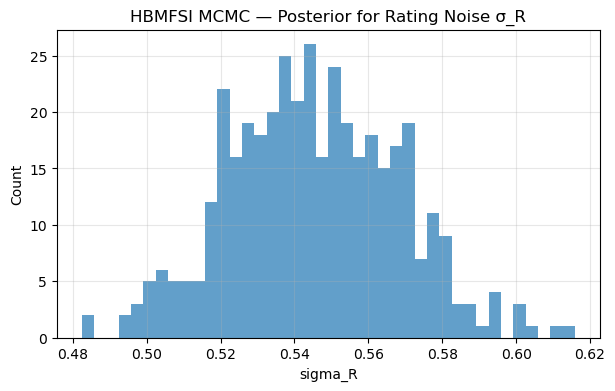

In [60]:
# ============================================================
# CELL 7 — Plots for MCMC HBMFSI on subset
# ============================================================

# 1) Predicted vs Actual ratings (warm subset test)
plt.figure(figsize=(6, 6))
plt.scatter(mcmc_r_test.cpu().numpy(),
            mcmc_pred_mean.numpy(),
            alpha=0.3, s=10)
plt.plot([1, 5], [1, 5], "r--")

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("HBMFSI MCMC — Predicted vs Actual (Warm Subset)")
plt.grid(True, alpha=0.3)
plt.show()

# 2) Posterior distribution of sigma_R (noise scale)
sigma_R_samples = mcmc_samples["sigma_R"].cpu().numpy()

plt.figure(figsize=(7, 4))
plt.hist(sigma_R_samples, bins=40, alpha=0.7)
plt.xlabel("sigma_R")
plt.ylabel("Count")
plt.title("HBMFSI MCMC — Posterior for Rating Noise σ_R")
plt.grid(True, alpha=0.3)
plt.show()


In [61]:
# ============================================================
# CELL — Helper: index → raw ID mappings
# ============================================================

# Maps *latent index* (0..num_users-1) back to original MovieLens user_id
index_to_user_id = {idx: uid for uid, idx in user_id_to_index.items()}

# Maps *latent index* (0..num_items-1) back to original MovieLens movie_id
index_to_item_id = {idx: iid for iid, idx in item_id_to_index.items()}

print("Mappings ready:")
print(f"  Users: {len(index_to_user_id)} | Items: {len(index_to_item_id)}")


Mappings ready:
  Users: 943 | Items: 1682


In [62]:
# ============================================================
# CELL — MCMC Cold-Start USERS evaluation
# ============================================================

# ---- 1) Reconstruct rating-level cold-user set consistent with the MCMC subset ----
warm_user_set = set(mcmc_users.cpu().tolist())       # users used in MCMC warm subset
warm_item_set = set(mcmc_items.cpu().tolist())       # items used in MCMC warm subset
cold_user_set = set(mcmc_cold_users.cpu().tolist())  # users treated as "cold" for MCMC

# Mask over the original warm-train ratings:
# (user in cold_user_set) AND (item in warm_item_set)
cold_user_mask_list = [
    (int(u) in cold_user_set) and (int(i) in warm_item_set)
    for u, i in zip(warm_user_idx_train, warm_item_idx_train)
]
cold_user_mask = torch.tensor(
    cold_user_mask_list,
    dtype=torch.bool,
    device=warm_user_idx_train.device,
)

u_cold_global_eval = warm_user_idx_train[cold_user_mask]  # global user indices (0..num_users-1)
i_cold_global_eval = warm_item_idx_train[cold_user_mask]  # global item indices (0..num_items-1)
r_cold_user_eval   = warm_r_train[cold_user_mask]         # true ratings

print(f"# rating-level cold-user pairs: {len(r_cold_user_eval)}")

# Map item global indices → local indices in the MCMC subset
item_global_to_local = {
    int(i): idx for idx, i in enumerate(mcmc_items.cpu().tolist())
}

i_cold_local_eval = torch.tensor(
    [item_global_to_local[int(i)] for i in i_cold_global_eval.cpu()],
    dtype=torch.long,
)

# ---- 2) Predict with mcmc_predict_new_user ----
pred_list = []
unc_list  = []

for u_idx, i_loc in zip(u_cold_global_eval.cpu().tolist(),
                         i_cold_local_eval.cpu().tolist()):
    # Convert latent index → original user_id
    raw_user_id = index_to_user_id[u_idx]

    pred_mean_t, pred_std_t = mcmc_predict_new_user(
        mcmc_samples,
        F_torch,            # full user feature matrix
        user_id_to_index,   # mapping from raw user_id → index
        raw_user_id,        # this user is "new" for the subset model
        [i_loc],            # predict for a single item in the subset
        mcmc_global_mean,
    )

    pred_list.append(float(pred_mean_t[0]))
    unc_list.append(float(pred_std_t[0]))

pred_arr   = np.array(pred_list, dtype=np.float32)
target_arr = r_cold_user_eval.cpu().numpy().astype(np.float32)

rmse_cu = float(np.sqrt(np.mean((pred_arr - target_arr) ** 2)))
mae_cu  = float(np.mean(np.abs(pred_arr - target_arr)))

print("\n===== MCMC Cold-Start USERS Evaluation =====")
print(f"# unique cold users: {len(cold_user_set)}")
print(f"# ratings used     : {len(target_arr)}")
print(f"RMSE: {rmse_cu:.4f}")
print(f"MAE : {mae_cu:.4f}")
print(f"Avg predictive std: {np.mean(unc_list):.4f}")


# rating-level cold-user pairs: 952

===== MCMC Cold-Start USERS Evaluation =====
# unique cold users: 50
# ratings used     : 952
RMSE: 0.9299
MAE : 0.7469
Avg predictive std: 0.6405


In [63]:
# ============================================================
# CELL — MCMC Cold-Start ITEMS evaluation
# ============================================================

# ---- 1) Reconstruct rating-level cold-item set consistent with the MCMC subset ----
warm_user_set = set(mcmc_users.cpu().tolist())
warm_item_set = set(mcmc_items.cpu().tolist())
cold_item_set = set(mcmc_cold_items.cpu().tolist())

# Mask: (item in cold_item_set) AND (user in warm_user_set)
cold_item_mask_list = [
    (int(i) in cold_item_set) and (int(u) in warm_user_set)
    for u, i in zip(warm_user_idx_train, warm_item_idx_train)
]
cold_item_mask = torch.tensor(
    cold_item_mask_list,
    dtype=torch.bool,
    device=warm_user_idx_train.device,
)

u_cold_item_global_eval = warm_user_idx_train[cold_item_mask]  # global user indices
i_cold_item_global_eval = warm_item_idx_train[cold_item_mask]  # global item indices
r_cold_item_eval        = warm_r_train[cold_item_mask]         # true ratings

print(f"# rating-level cold-item pairs: {len(r_cold_item_eval)}")

# Map user global indices → local indices in the MCMC subset
user_global_to_local = {
    int(u): idx for idx, u in enumerate(mcmc_users.cpu().tolist())
}

u_cold_item_local_eval = torch.tensor(
    [user_global_to_local[int(u)] for u in u_cold_item_global_eval.cpu()],
    dtype=torch.long,
)

# ---- 2) Predict with mcmc_predict_new_item ----
pred_list_items = []
unc_list_items  = []

for u_loc, i_idx in zip(u_cold_item_local_eval.cpu().tolist(),
                        i_cold_item_global_eval.cpu().tolist()):
    # latent index → original movie_id
    raw_item_id = index_to_item_id[i_idx]

    pred_mean_t, pred_std_t = mcmc_predict_new_item(
        mcmc_samples,
        G_torch,            # full item feature matrix
        item_id_to_index,   # mapping from raw movie_id → index
        raw_item_id,        # this item is "new" for the subset model
        [u_loc],            # predict for a single user in the subset
        mcmc_global_mean,
    )

    pred_list_items.append(float(pred_mean_t[0]))
    unc_list_items.append(float(pred_std_t[0]))

pred_items   = np.array(pred_list_items, dtype=np.float32)
target_items = r_cold_item_eval.cpu().numpy().astype(np.float32)

rmse_ci = float(np.sqrt(np.mean((pred_items - target_items) ** 2)))
mae_ci  = float(np.mean(np.abs(pred_items - target_items)))

print("\n===== MCMC Cold-Start ITEMS Evaluation =====")
print(f"# unique cold items: {len(cold_item_set)}")
print(f"# ratings used     : {len(target_items)}")
print(f"RMSE: {rmse_ci:.4f}")
print(f"MAE : {mae_ci:.4f}")
print(f"Avg predictive std: {np.mean(unc_list_items):.4f}")


# rating-level cold-item pairs: 1298

===== MCMC Cold-Start ITEMS Evaluation =====
# unique cold items: 100
# ratings used     : 1298
RMSE: 1.0792
MAE : 0.8686
Avg predictive std: 0.6578


===== MCMC Warm-Subset Predictive Coverage =====
95% predictive interval coverage: 96.41%
Avg predictive std (warm): 0.9363


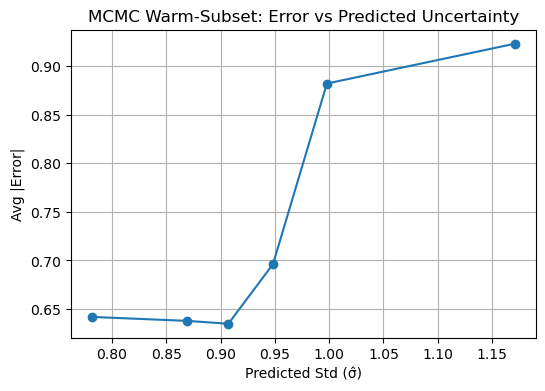

In [66]:
# ============================================================
# CELL — MCMC Predictive Coverage & Calibration (Warm Subset)
# ============================================================

# Assuming you already have:
#   mcmc_warm_user_idx_test, mcmc_warm_item_idx_test, mcmc_warm_r_test
#   mcmc_samples, mcmc_global_mean
#   and a function: mcmc_predict_existing_pairs(samples, u_tensor, i_tensor, global_mean)

# 1) Get predictive mean and std for all warm-test pairs
u_test = mcmc_u_test
i_test = mcmc_i_test
r_true = mcmc_r_test.cpu().numpy().astype(np.float32)

mean_pred_t, std_pred_t = mcmc_predict_existing_pairs(
    mcmc_samples,
    u_test,
    i_test,
    mcmc_global_mean,
)

mean_pred = mean_pred_t.cpu().numpy().astype(np.float32)
std_pred  = std_pred_t.cpu().numpy().astype(np.float32)

# 2) 95% predictive intervals and coverage
lower = np.clip(mean_pred - 1.96 * std_pred, 1.0, 5.0)
upper = np.clip(mean_pred + 1.96 * std_pred, 1.0, 5.0)

inside = (r_true >= lower) & (r_true <= upper)
coverage_95 = inside.mean()

print("===== MCMC Warm-Subset Predictive Coverage =====")
print(f"95% predictive interval coverage: {coverage_95 * 100:.2f}%")
print(f"Avg predictive std (warm): {std_pred.mean():.4f}")

# 3) Simple calibration: error vs. predicted std (binned)
abs_err = np.abs(mean_pred - r_true)

num_bins = 6
bins = np.quantile(std_pred, np.linspace(0.0, 1.0, num_bins + 1))
bin_centers = 0.5 * (bins[:-1] + bins[1:])
avg_abs_err = []

for b_lo, b_hi in zip(bins[:-1], bins[1:]):
    mask = (std_pred >= b_lo) & (std_pred < b_hi)
    if mask.sum() == 0:
        avg_abs_err.append(np.nan)
    else:
        avg_abs_err.append(abs_err[mask].mean())

plt.figure(figsize=(6, 4))
plt.plot(bin_centers, avg_abs_err, marker="o")
plt.xlabel("Predicted Std (σ̂)")
plt.ylabel("Avg |Error|")
plt.title("MCMC Warm-Subset: Error vs Predicted Uncertainty")
plt.grid(True)
plt.show()


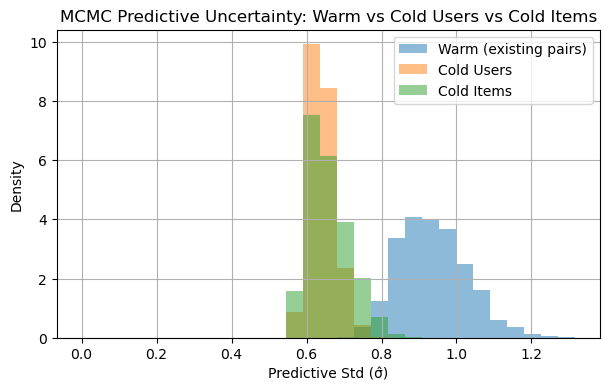

Avg std — Warm      : 0.9362525343894958
Avg std — Cold users: 0.6404547095298767
Avg std — Cold items: 0.6577525734901428


In [67]:
# ============================================================
# CELL — Predictive Std Distribution: Warm vs Cold Users vs Cold Items
# ============================================================

# Convert to numpy arrays
std_warm       = std_pred  # from previous cell
std_cold_users = np.array(unc_list, dtype=np.float32)          # from cold-user eval cell
std_cold_items = np.array(unc_list_items, dtype=np.float32)    # from cold-item eval cell

plt.figure(figsize=(7, 4))
bins = np.linspace(0.0, max(std_warm.max(), std_cold_users.max(), std_cold_items.max()), 30)

plt.hist(std_warm,       bins=bins, alpha=0.5, density=True, label="Warm (existing pairs)")
plt.hist(std_cold_users, bins=bins, alpha=0.5, density=True, label="Cold Users")
plt.hist(std_cold_items, bins=bins, alpha=0.5, density=True, label="Cold Items")

plt.xlabel("Predictive Std (σ̂)")
plt.ylabel("Density")
plt.title("MCMC Predictive Uncertainty: Warm vs Cold Users vs Cold Items")
plt.legend()
plt.grid(True)
plt.show()

print("Avg std — Warm      :", float(std_warm.mean()))
print("Avg std — Cold users:", float(std_cold_users.mean()))
print("Avg std — Cold items:", float(std_cold_items.mean()))


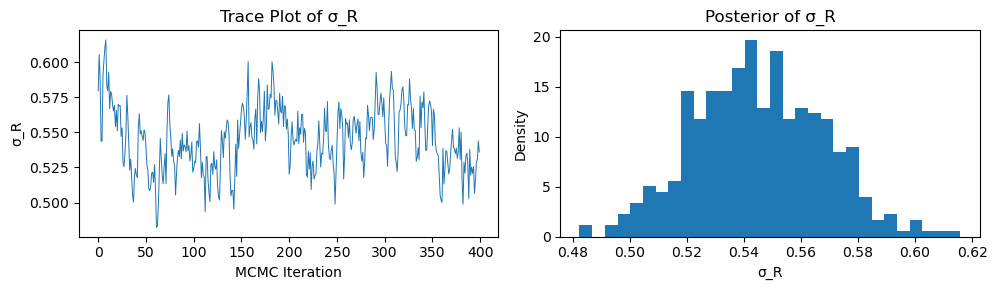

Posterior mean σ_R: 0.5452
Posterior std  σ_R: 0.0228


In [68]:
# ============================================================
# CELL — Posterior Trace & Histogram for σ_R (Rating Noise)
# ============================================================

# Assuming Pyro stored it as "sigma_R" in mcmc_samples
sigma_R_samples = mcmc_samples["sigma_R"].detach().cpu().numpy().flatten()

plt.figure(figsize=(10, 3))

# (a) Trace plot
plt.subplot(1, 2, 1)
plt.plot(sigma_R_samples, linewidth=0.7)
plt.xlabel("MCMC Iteration")
plt.ylabel("σ_R")
plt.title("Trace Plot of σ_R")

# (b) Posterior histogram
plt.subplot(1, 2, 2)
plt.hist(sigma_R_samples, bins=30, density=True)
plt.xlabel("σ_R")
plt.ylabel("Density")
plt.title("Posterior of σ_R")

plt.tight_layout()
plt.show()

print(f"Posterior mean σ_R: {sigma_R_samples.mean():.4f}")
print(f"Posterior std  σ_R: {sigma_R_samples.std():.4f}")
